# MelCNN MGR Manifest, Log-Mel, and TFRecord EDA

This notebook audits the current MelCNN MGR preprocessing pipeline after the staged command sequence below:

1. `python MelCNN-MGR/preprocessing/1_build_all_datasets_and_samples_v1_1.py --mode stage1 --stage1a-sources fma --stage1b-sources fma`
2. `python MelCNN-MGR/preprocessing/1_build_all_datasets_and_samples_v1_1.py --mode stage1 --stage1a-sources additional --stage1b-sources additional`
3. `python MelCNN-MGR/preprocessing/1_build_all_datasets_and_samples_v1_1.py --mode stage2`
4. `python MelCNN-MGR/preprocessing/2_build_log_mel_dataset.py`
5. `python MelCNN-MGR/preprocessing/3_convert_npy_2_tfrecord.py`

The audit is centered on the live artifacts produced by those steps:

1. source-split processed manifests in `MelCNN-MGR/data/processed`
2. the final selected segment manifest in `MelCNN-MGR/data/processed/manifest_final_samples.parquet`
3. generated log-mel outputs under the active log-mel dataset root
4. generated TFRecord outputs under the active TFRecord dataset root
5. optional latest training metadata when a downstream model run report also exists

The goal is to verify that the staged multi-source pipeline remains coherent from file discovery, to segment generation, to final split selection, to log-mel materialization, and finally to TFRecord conversion.

## Notebook Map

The notebook follows the staged preprocessing pipeline in execution order and then inspects any optional downstream training metadata that happens to be present:

1. resolve repo paths and detect the active generated downstream roots
2. inspect processed manifest artifacts and schema contracts
3. audit file-level discovery and skip logic across FMA and additional sources
4. audit segment expansion and final split selection
5. check leakage safety and additional-source contribution
6. keep the small-split supplementation audit as an optional branch when those artifacts exist
7. inspect downstream log-mel manifests and build reports
8. inspect downstream TFRecord manifests, shard indexes, and build reports
9. inspect the latest saved training run report only if one exists
10. summarize readiness, divergence, and remaining gaps

In [23]:
from __future__ import annotations

import hashlib
import json
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 160)

NOTEBOOK_NAME = 'MelCNN_MGR_Manifest_LogMel_EDA'
DEFAULT_SAMPLE_LENGTH_SEC = 15.0


def resolve_project_paths(start: Path) -> tuple[Path, Path]:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / 'MelCNN-MGR' / 'settings.json').exists():
            return candidate, candidate / 'MelCNN-MGR'
        if candidate.name == 'MelCNN-MGR' and (candidate / 'settings.json').exists():
            return candidate.parent, candidate
    raise FileNotFoundError('Could not locate workspace root containing MelCNN-MGR/settings.json')


def safe_read_json(path: Path | None) -> dict[str, object] | None:
    if path is None or not path.exists():
        return None
    return json.loads(path.read_text())


def optional_path_from_value(value: object) -> Path | None:
    if not isinstance(value, str):
        return None
    stripped = value.strip()
    if not stripped:
        return None
    return Path(stripped).expanduser()


def first_existing(paths: list[Path | None]) -> Path | None:
    seen: set[str] = set()
    for path in paths:
        if path is None:
            continue
        candidate = path.expanduser()
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if candidate.exists():
            return candidate
    return None


def load_data_sampling_settings(settings_path: Path) -> dict[str, object]:
    settings_payload = safe_read_json(settings_path)
    config = {} if not isinstance(settings_payload, dict) else settings_payload.get('data_sampling_settings', {})
    return config if isinstance(config, dict) else {}


def positive_float_or_default(value: object, default: float) -> float:
    if isinstance(value, (int, float)) and value > 0:
        return float(value)
    return default


def sample_length_label(sample_length_sec: float) -> str:
    return f'{sample_length_sec:g}s'


def find_latest_matching_dir(
    base_dirs: list[Path],
    pattern: str,
    required_files: list[str],
    exclude_suffix: str | None = None,
) -> Path | None:
    matches: list[Path] = []
    for base_dir in base_dirs:
        if not base_dir.exists():
            continue
        for path in base_dir.glob(pattern):
            if not path.is_dir():
                continue
            if exclude_suffix and path.name.endswith(exclude_suffix):
                continue
            if not all((path / filename).exists() for filename in required_files):
                continue
            matches.append(path)
    if not matches:
        return None
    return max(
        matches,
        key=lambda path: max((path / filename).stat().st_mtime for filename in required_files),
    )


WORKSPACE_ROOT, MELCNN_DIR = resolve_project_paths(Path.cwd())
PROCESSED_DIR = MELCNN_DIR / 'data' / 'processed'
SETTINGS_PATH = MELCNN_DIR / 'settings.json'
TRACKS_CSV = WORKSPACE_ROOT / 'FMA' / 'fma_metadata' / 'tracks.csv'
EXTRA_SAMPLES_PATH = PROCESSED_DIR / 'extra_samples_for_small_dataset.json'

DATA_SAMPLING_SETTINGS = load_data_sampling_settings(SETTINGS_PATH)
CONFIGURED_SAMPLE_LENGTH_SEC = positive_float_or_default(
    DATA_SAMPLING_SETTINGS.get('sample_length_sec'),
    DEFAULT_SAMPLE_LENGTH_SEC,
)
SAMPLE_LENGTH_LABEL = sample_length_label(CONFIGURED_SAMPLE_LENGTH_SEC)

FMA_DATASETS_PATH = PROCESSED_DIR / 'manifest_fma_datasets.parquet'
FMA_ALL_SAMPLES_PATH = PROCESSED_DIR / 'manifest_fma_all_samples.parquet'
ADDITIONAL_DATASETS_PATH = PROCESSED_DIR / 'manifest_additional_datasets.parquet'
ADDITIONAL_ALL_SAMPLES_PATH = PROCESSED_DIR / 'manifest_additional_all_samples.parquet'
FINAL_SAMPLES_PATH = PROCESSED_DIR / 'manifest_final_samples.parquet'
FINAL_CONFIG_PATH = PROCESSED_DIR / 'manifest_final_samples.config.json'
FINAL_REPORT_PATH = PROCESSED_DIR / 'manifest_final_samples.report.txt'

SOURCE_DATASET_PATHS = {
    'fma': FMA_DATASETS_PATH,
    'additional': ADDITIONAL_DATASETS_PATH,
}
SOURCE_SAMPLE_PATHS = {
    'fma': FMA_ALL_SAMPLES_PATH,
    'additional': ADDITIONAL_ALL_SAMPLES_PATH,
}

SUPPLEMENTED_TARGET_SUBSET = 'small'
SUPPLEMENTED_SPLIT_ORDER = ['training', 'validation', 'test']
SUPPLEMENTED_SPLIT_FILES = {
    'training': f'train_{SUPPLEMENTED_TARGET_SUBSET}.parquet',
    'validation': f'val_{SUPPLEMENTED_TARGET_SUBSET}.parquet',
    'test': f'test_{SUPPLEMENTED_TARGET_SUBSET}.parquet',
}
SUPPLEMENTATION_BASE_RANDOM_SEED = 20260309

PIPELINE_COMMANDS = [
    'python MelCNN-MGR/preprocessing/1_build_all_datasets_and_samples_v1_1.py --mode stage1 --stage1a-sources fma --stage1b-sources fma',
    'python MelCNN-MGR/preprocessing/1_build_all_datasets_and_samples_v1_1.py --mode stage1 --stage1a-sources additional --stage1b-sources additional',
    'python MelCNN-MGR/preprocessing/1_build_all_datasets_and_samples_v1_1.py --mode stage2',
    'python MelCNN-MGR/preprocessing/2_build_log_mel_dataset.py',
    'python MelCNN-MGR/preprocessing/3_convert_npy_2_tfrecord.py',
]

run_report_candidates = sorted((MELCNN_DIR / 'demo-models').glob('**/run_report_*.json'))
run_report_candidates += sorted((MELCNN_DIR / 'models').glob('**/run_report_*.json'))
LATEST_RUN_REPORT_PATH = max(run_report_candidates, key=lambda path: path.stat().st_mtime) if run_report_candidates else None
LATEST_RUN_REPORT = safe_read_json(LATEST_RUN_REPORT_PATH)
LATEST_RUN_DIR = None if LATEST_RUN_REPORT_PATH is None else LATEST_RUN_REPORT_PATH.parent

CACHE_ROOTS = [
    Path('/home/hsnguyen/model-training-data-cache'),
    MELCNN_DIR / 'cache',
]
LATEST_DISCOVERED_LOGMEL_DIR = find_latest_matching_dir(
    CACHE_ROOTS,
    pattern='logmel_dataset_*',
    required_files=['logmel_config.json', 'logmel_manifest_all.parquet'],
    exclude_suffix='_tfrecord',
)
LATEST_DISCOVERED_TFRECORD_DIR = find_latest_matching_dir(
    CACHE_ROOTS,
    pattern='logmel_dataset_*_tfrecord',
    required_files=['tfrecord_config.json', 'tfrecord_manifest_all.parquet'],
)

run_report_logmel_dir = None if not isinstance(LATEST_RUN_REPORT, dict) else optional_path_from_value(LATEST_RUN_REPORT.get('source_logmel_root'))
run_report_tfrecord_dir = None if not isinstance(LATEST_RUN_REPORT, dict) else optional_path_from_value(LATEST_RUN_REPORT.get('tfrecord_dataset_dir'))

logmel_dir_candidates = [
    run_report_logmel_dir,
    CACHE_ROOTS[0] / f'logmel_dataset_{SAMPLE_LENGTH_LABEL}',
    CACHE_ROOTS[1] / f'logmel_dataset_{SAMPLE_LENGTH_LABEL}',
    LATEST_DISCOVERED_LOGMEL_DIR,
]
tfrecord_dir_candidates = [
    run_report_tfrecord_dir,
    CACHE_ROOTS[0] / f'logmel_dataset_{SAMPLE_LENGTH_LABEL}_tfrecord',
    CACHE_ROOTS[1] / f'logmel_dataset_{SAMPLE_LENGTH_LABEL}_tfrecord',
    LATEST_DISCOVERED_TFRECORD_DIR,
]

LOGMEL_DATASET_DIR = first_existing(logmel_dir_candidates)
TFRECORD_DATASET_DIR = first_existing(tfrecord_dir_candidates)

LOGMEL_CONFIG_PATH = None if LOGMEL_DATASET_DIR is None else LOGMEL_DATASET_DIR / 'logmel_config.json'
LOGMEL_ALL_PATH = None if LOGMEL_DATASET_DIR is None else LOGMEL_DATASET_DIR / 'logmel_manifest_all.parquet'
LOGMEL_TRAIN_PATH = None if LOGMEL_DATASET_DIR is None else LOGMEL_DATASET_DIR / 'logmel_manifest_train.parquet'
LOGMEL_VAL_PATH = None if LOGMEL_DATASET_DIR is None else LOGMEL_DATASET_DIR / 'logmel_manifest_val.parquet'
LOGMEL_TEST_PATH = None if LOGMEL_DATASET_DIR is None else LOGMEL_DATASET_DIR / 'logmel_manifest_test.parquet'
LOGMEL_BUILD_REPORT_PATH = None if LOGMEL_DATASET_DIR is None else LOGMEL_DATASET_DIR / 'logmel_build_report.txt'

TFRECORD_CONFIG_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_config.json'
TFRECORD_ALL_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_manifest_all.parquet'
TFRECORD_TRAIN_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_manifest_train.parquet'
TFRECORD_VAL_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_manifest_val.parquet'
TFRECORD_TEST_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_manifest_test.parquet'
TFRECORD_SHARDS_ALL_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_shards_all.parquet'
TFRECORD_SHARDS_TRAIN_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_shards_train.parquet'
TFRECORD_SHARDS_VAL_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_shards_val.parquet'
TFRECORD_SHARDS_TEST_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_shards_test.parquet'
TFRECORD_BUILD_REPORT_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_build_report.txt'

print(f'Loaded helpers for {NOTEBOOK_NAME}')
print(f'Workspace root               : {WORKSPACE_ROOT}')
print(f'Processed dir                : {PROCESSED_DIR}')
print(f'Configured sample length sec : {CONFIGURED_SAMPLE_LENGTH_SEC}')
print(f'Latest run report            : {LATEST_RUN_REPORT_PATH}')
print(f'Latest run dir               : {LATEST_RUN_DIR}')
print(f'Detected log-mel dataset dir : {LOGMEL_DATASET_DIR}')
print(f'Detected TFRecord dataset dir: {TFRECORD_DATASET_DIR}')

Loaded helpers for MelCNN_MGR_Manifest_LogMel_EDA
Workspace root               : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1
Processed dir                : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed
Configured sample length sec : 15.0
Latest run report            : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/models/baseline_logmel-cnn-20260321-070615/run_report_small.json
Latest run dir               : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/models/baseline_logmel-cnn-20260321-070615
Detected log-mel dataset dir : /home/hsnguyen/model-training-data-cache/logmel_dataset_15s
Detected TFRecord dataset dir: /home/hsnguyen/model-training-data-cache/logmel_dataset_15s_tfrecord


In [24]:
def display_frame_overview(name: str, frame: pd.DataFrame, head_rows: int = 5) -> None:
    display(Markdown(f'### {name}'))
    print(f'shape = {frame.shape}')
    display(frame.head(head_rows))
    dtype_frame = pd.DataFrame({
        'column': frame.columns,
        'dtype': [str(dtype) for dtype in frame.dtypes],
        'null_count': frame.isna().sum().values,
        'null_pct': (frame.isna().mean() * 100).round(2).values,
    })
    display(dtype_frame)


def display_json_table(title: str, payload: dict[str, object] | None) -> None:
    display(Markdown(f'### {title}'))
    if not payload:
        print('Not available.')
        return
    rows = []
    for key, value in payload.items():
        if isinstance(value, (dict, list)):
            rows.append({'key': key, 'value': json.dumps(value, ensure_ascii=False)[:300]})
        else:
            rows.append({'key': key, 'value': value})
    display(pd.DataFrame(rows))


def imbalance_table(series: pd.Series, name: str | None = None) -> pd.DataFrame:
    counts = series.value_counts(dropna=False)
    label = name or series.name or 'category'
    if counts.empty:
        return pd.DataFrame(columns=[label, 'count', 'proportion_pct', 'imbalance_ratio_vs_max'])
    table = counts.rename_axis(label).reset_index(name='count')
    table['proportion_pct'] = (table['count'] / table['count'].sum() * 100).round(2)
    table['imbalance_ratio_vs_max'] = (table['count'].max() / table['count']).round(3)
    return table


def plot_bar(series: pd.Series, title: str, xlabel: str = '', ylabel: str = 'count', rotation: int = 45, figsize: tuple[int, int] = (10, 5), color: str = '#4C78A8') -> None:
    data = series.sort_values(ascending=False)
    _, ax = plt.subplots(figsize=figsize)
    data.plot(kind='bar', ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_hist(series: pd.Series, title: str, bins: int = 40, figsize: tuple[int, int] = (10, 5), color: str = '#72B7B2') -> None:
    clean = pd.to_numeric(series, errors='coerce').dropna()
    _, ax = plt.subplots(figsize=figsize)
    ax.hist(clean, bins=bins, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(series.name or 'value')
    ax.set_ylabel('count')
    plt.tight_layout()
    plt.show()


def plot_heatmap(table: pd.DataFrame, title: str, figsize: tuple[int, int] = (10, 6), fmt: str = '.0f') -> None:
    numeric_table = table.apply(pd.to_numeric, errors='coerce')
    if numeric_table.empty:
        print(f'No data available for {title}')
        return
    _, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(numeric_table.values, aspect='auto', cmap='YlGnBu')
    ax.set_xticks(np.arange(numeric_table.shape[1]))
    ax.set_yticks(np.arange(numeric_table.shape[0]))
    ax.set_xticklabels(numeric_table.columns)
    ax.set_yticklabels(numeric_table.index)
    for i in range(numeric_table.shape[0]):
        for j in range(numeric_table.shape[1]):
            value = numeric_table.values[i, j]
            label = '' if pd.isna(value) else format(value, fmt)
            ax.text(j, i, label, ha='center', va='center', color='black', fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def artifact_id_from_sample_id(sample_id: str) -> str:
    return re.sub(r':seg\d+$', '', str(sample_id))


def safe_read_parquet(path: Path | None) -> pd.DataFrame | None:
    if path is None or not path.exists():
        return None
    return pd.read_parquet(path)


def combine_frames(frames: dict[str, pd.DataFrame | None]) -> pd.DataFrame:
    available = [frame.assign(_source_manifest=name) for name, frame in frames.items() if frame is not None]
    if not available:
        return pd.DataFrame()
    return pd.concat(available, axis=0, ignore_index=True)


def build_schema_check(artifact: str, frame: pd.DataFrame | None, expected_columns: list[str]) -> dict[str, object]:
    if frame is None:
        return {
            'artifact': artifact,
            'exists': False,
            'expected_columns_match': False,
            'missing_columns': expected_columns,
            'extra_columns': [],
        }
    return {
        'artifact': artifact,
        'exists': True,
        'expected_columns_match': list(frame.columns) == expected_columns,
        'missing_columns': sorted(set(expected_columns) - set(frame.columns)),
        'extra_columns': sorted(set(frame.columns) - set(expected_columns)),
    }

In [25]:
settings_payload = safe_read_json(SETTINGS_PATH)
final_manifest_config = safe_read_json(FINAL_CONFIG_PATH)
logmel_config = safe_read_json(LOGMEL_CONFIG_PATH)
tfrecord_config = safe_read_json(TFRECORD_CONFIG_PATH)
run_report = LATEST_RUN_REPORT
manifest_report_preview = FINAL_REPORT_PATH.read_text().splitlines()[:80] if FINAL_REPORT_PATH.exists() else []
logmel_report_preview = LOGMEL_BUILD_REPORT_PATH.read_text().splitlines()[:60] if LOGMEL_BUILD_REPORT_PATH is not None and LOGMEL_BUILD_REPORT_PATH.exists() else []
tfrecord_report_preview = TFRECORD_BUILD_REPORT_PATH.read_text().splitlines()[:60] if TFRECORD_BUILD_REPORT_PATH is not None and TFRECORD_BUILD_REPORT_PATH.exists() else []

source_dataset_frames = {name: safe_read_parquet(path) for name, path in SOURCE_DATASET_PATHS.items()}
source_sample_frames = {name: safe_read_parquet(path) for name, path in SOURCE_SAMPLE_PATHS.items()}

fma_datasets_df = source_dataset_frames.get('fma')
additional_datasets_df = source_dataset_frames.get('additional')
fma_all_samples_df = source_sample_frames.get('fma')
additional_all_samples_df = source_sample_frames.get('additional')

all_datasets_df = combine_frames(source_dataset_frames)
all_samples_df = combine_frames(source_sample_frames)
final_samples_df = pd.read_parquet(FINAL_SAMPLES_PATH)

logmel_all_df = safe_read_parquet(LOGMEL_ALL_PATH)
logmel_train_df = safe_read_parquet(LOGMEL_TRAIN_PATH)
logmel_val_df = safe_read_parquet(LOGMEL_VAL_PATH)
logmel_test_df = safe_read_parquet(LOGMEL_TEST_PATH)

tfrecord_all_df = safe_read_parquet(TFRECORD_ALL_PATH)
tfrecord_train_df = safe_read_parquet(TFRECORD_TRAIN_PATH)
tfrecord_val_df = safe_read_parquet(TFRECORD_VAL_PATH)
tfrecord_test_df = safe_read_parquet(TFRECORD_TEST_PATH)
tfrecord_shards_all_df = safe_read_parquet(TFRECORD_SHARDS_ALL_PATH)
tfrecord_shards_train_df = safe_read_parquet(TFRECORD_SHARDS_TRAIN_PATH)
tfrecord_shards_val_df = safe_read_parquet(TFRECORD_SHARDS_VAL_PATH)
tfrecord_shards_test_df = safe_read_parquet(TFRECORD_SHARDS_TEST_PATH)

sampling_settings = (settings_payload or {}).get('data_sampling_settings', {})
model_inference_settings = (settings_payload or {}).get('model_inference_settings', {})

artifact_rows = [
    {'artifact': 'manifest_fma_datasets', 'path': str(FMA_DATASETS_PATH), 'exists': FMA_DATASETS_PATH.exists(), 'rows': 0 if fma_datasets_df is None else len(fma_datasets_df), 'columns': 0 if fma_datasets_df is None else fma_datasets_df.shape[1]},
    {'artifact': 'manifest_additional_datasets', 'path': str(ADDITIONAL_DATASETS_PATH), 'exists': ADDITIONAL_DATASETS_PATH.exists(), 'rows': 0 if additional_datasets_df is None else len(additional_datasets_df), 'columns': 0 if additional_datasets_df is None else additional_datasets_df.shape[1]},
    {'artifact': 'manifest_fma_all_samples', 'path': str(FMA_ALL_SAMPLES_PATH), 'exists': FMA_ALL_SAMPLES_PATH.exists(), 'rows': 0 if fma_all_samples_df is None else len(fma_all_samples_df), 'columns': 0 if fma_all_samples_df is None else fma_all_samples_df.shape[1]},
    {'artifact': 'manifest_additional_all_samples', 'path': str(ADDITIONAL_ALL_SAMPLES_PATH), 'exists': ADDITIONAL_ALL_SAMPLES_PATH.exists(), 'rows': 0 if additional_all_samples_df is None else len(additional_all_samples_df), 'columns': 0 if additional_all_samples_df is None else additional_all_samples_df.shape[1]},
    {'artifact': 'manifest_final_samples', 'path': str(FINAL_SAMPLES_PATH), 'exists': FINAL_SAMPLES_PATH.exists(), 'rows': len(final_samples_df), 'columns': final_samples_df.shape[1]},
    {'artifact': 'logmel_build_report', 'path': None if LOGMEL_BUILD_REPORT_PATH is None else str(LOGMEL_BUILD_REPORT_PATH), 'exists': LOGMEL_BUILD_REPORT_PATH is not None and LOGMEL_BUILD_REPORT_PATH.exists(), 'rows': None, 'columns': None},
    {'artifact': 'logmel_manifest_all', 'path': None if LOGMEL_ALL_PATH is None else str(LOGMEL_ALL_PATH), 'exists': LOGMEL_ALL_PATH is not None and LOGMEL_ALL_PATH.exists(), 'rows': 0 if logmel_all_df is None else len(logmel_all_df), 'columns': 0 if logmel_all_df is None else logmel_all_df.shape[1]},
    {'artifact': 'tfrecord_build_report', 'path': None if TFRECORD_BUILD_REPORT_PATH is None else str(TFRECORD_BUILD_REPORT_PATH), 'exists': TFRECORD_BUILD_REPORT_PATH is not None and TFRECORD_BUILD_REPORT_PATH.exists(), 'rows': None, 'columns': None},
    {'artifact': 'tfrecord_manifest_all', 'path': None if TFRECORD_ALL_PATH is None else str(TFRECORD_ALL_PATH), 'exists': TFRECORD_ALL_PATH is not None and TFRECORD_ALL_PATH.exists(), 'rows': 0 if tfrecord_all_df is None else len(tfrecord_all_df), 'columns': 0 if tfrecord_all_df is None else tfrecord_all_df.shape[1]},
    {'artifact': 'tfrecord_shards_all', 'path': None if TFRECORD_SHARDS_ALL_PATH is None else str(TFRECORD_SHARDS_ALL_PATH), 'exists': TFRECORD_SHARDS_ALL_PATH is not None and TFRECORD_SHARDS_ALL_PATH.exists(), 'rows': 0 if tfrecord_shards_all_df is None else len(tfrecord_shards_all_df), 'columns': 0 if tfrecord_shards_all_df is None else tfrecord_shards_all_df.shape[1]},
    {'artifact': 'latest_run_report', 'path': None if LATEST_RUN_REPORT_PATH is None else str(LATEST_RUN_REPORT_PATH), 'exists': LATEST_RUN_REPORT_PATH is not None and LATEST_RUN_REPORT_PATH.exists(), 'rows': None, 'columns': None},
]
artifact_inventory = pd.DataFrame(artifact_rows)

pipeline_rows = pd.DataFrame([{'step': step_index, 'command': command} for step_index, command in enumerate(PIPELINE_COMMANDS, start=1)])

config_rows = [
    {'key': 'workspace_root', 'value': str(WORKSPACE_ROOT)},
    {'key': 'melcnn_dir', 'value': str(MELCNN_DIR)},
    {'key': 'processed_dir', 'value': str(PROCESSED_DIR)},
    {'key': 'configured_sample_length_sec', 'value': CONFIGURED_SAMPLE_LENGTH_SEC},
    {'key': 'latest_run_report', 'value': None if LATEST_RUN_REPORT_PATH is None else str(LATEST_RUN_REPORT_PATH)},
    {'key': 'latest_run_id', 'value': None if not isinstance(run_report, dict) else run_report.get('run_id')},
    {'key': 'configured_demo_model_name', 'value': model_inference_settings.get('model_name')},
    {'key': 'logmel_dataset_dir', 'value': None if LOGMEL_DATASET_DIR is None else str(LOGMEL_DATASET_DIR)},
    {'key': 'tfrecord_dataset_dir', 'value': None if TFRECORD_DATASET_DIR is None else str(TFRECORD_DATASET_DIR)},
    {'key': 'target_genres', 'value': ', '.join(sampling_settings.get('target_genres', []))},
    {'key': 'sample_length_sec', 'value': sampling_settings.get('sample_length_sec')},
    {'key': 'number_of_samples_expected_each_genre', 'value': sampling_settings.get('number_of_samples_expected_each_genre')},
    {'key': 'additional_samples_contribution_ratio_expected_each_genre', 'value': sampling_settings.get('additional_samples_contribution_ratio_expected_each_genre')},
    {'key': 'train_n_val_test_split_ratio_each_genre', 'value': sampling_settings.get('train_n_val_test_split_ratio_each_genre')},
    {'key': 'final_manifest_generated_at', 'value': None if final_manifest_config is None else final_manifest_config.get('generated_at')},
    {'key': 'logmel_config_generated_at', 'value': None if logmel_config is None else logmel_config.get('generated_at')},
    {'key': 'tfrecord_config_generated_at', 'value': None if tfrecord_config is None else tfrecord_config.get('generated_at')},
    {'key': 'training_run_generated_at', 'value': None if not isinstance(run_report, dict) else run_report.get('generated_at')},
]

display(Markdown('## Staged Pipeline Commands'))
display(pipeline_rows)

display(Markdown('## Configuration and Artifact Presence'))
display(pd.DataFrame(config_rows))
display(artifact_inventory)

if manifest_report_preview:
    display(Markdown('## Final Manifest Report Preview'))
    print('\n'.join(manifest_report_preview))

if logmel_report_preview:
    display(Markdown('## Log-Mel Build Report Preview'))
    print('\n'.join(logmel_report_preview))

if tfrecord_report_preview:
    display(Markdown('## TFRecord Build Report Preview'))
    print('\n'.join(tfrecord_report_preview))

## Staged Pipeline Commands

,step,command
0,1,python MelCNN-MGR/preprocessing/1_build_all_datasets_and_samples_v1_1.py --mode stage1 --stage1a-sources fma --stage1b-sources fma
1,2,python MelCNN-MGR/preprocessing/1_build_all_datasets_and_samples_v1_1.py --mode stage1 --stage1a-sources additional --stage1b-sources additional
2,3,python MelCNN-MGR/preprocessing/1_build_all_datasets_and_samples_v1_1.py --mode stage2
3,4,python MelCNN-MGR/preprocessing/2_build_log_mel_dataset.py
4,5,python MelCNN-MGR/preprocessing/3_convert_npy_2_tfrecord.py


## Configuration and Artifact Presence

,key,value
0,workspace_root,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1
1,melcnn_dir,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR
2,processed_dir,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed
3,configured_sample_length_sec,15.0
4,latest_run_report,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/models/baseline_logmel-cnn-20260321-070615/run_report_small.json
5,latest_run_id,logmel-cnn-20260321-070615
6,configured_demo_model_name,logmel-cnn-v2_4-cuda-tf-20260318-104959_15s
7,logmel_dataset_dir,/home/hsnguyen/model-training-data-cache/logmel_dataset_15s
8,tfrecord_dataset_dir,/home/hsnguyen/model-training-data-cache/logmel_dataset_15s_tfrecord
9,target_genres,"Hip-Hop, Pop, Rock, Metal, Classical, Jazz, Country, Blues, Bolero, Speech"


,artifact,path,exists,rows,columns
0,manifest_fma_datasets,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_fma_datasets.parquet,True,14059.0,15.0
1,manifest_additional_datasets,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_additional_datasets.parquet,True,11158.0,15.0
2,manifest_fma_all_samples,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_fma_all_samples.parquet,True,28093.0,14.0
3,manifest_additional_all_samples,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_additional_all_samples.parquet,True,22093.0,14.0
4,manifest_final_samples,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_final_samples.parquet,True,24973.0,14.0
5,logmel_build_report,/home/hsnguyen/model-training-data-cache/logmel_dataset_15s/logmel_build_report.txt,True,NaN,NaN
6,logmel_manifest_all,/home/hsnguyen/model-training-data-cache/logmel_dataset_15s/logmel_manifest_all.parquet,True,22671.0,25.0
7,tfrecord_build_report,/home/hsnguyen/model-training-data-cache/logmel_dataset_15s_tfrecord/tfrecord_build_report.txt,True,NaN,NaN
8,tfrecord_manifest_all,/home/hsnguyen/model-training-data-cache/logmel_dataset_15s_tfrecord/tfrecord_manifest_all.parquet,True,22037.0,32.0
9,tfrecord_shards_all,/home/hsnguyen/model-training-data-cache/logmel_dataset_15s_tfrecord/tfrecord_shards_all.parquet,True,24.0,5.0


...

build_all_datasets_and_samples report
Generated : 2026-03-18 08:58:44 UTC

── Configuration ───────────────────────────────────────
  mode: stage2
  stage1a_sources: both
  stage1b_sources: both
  target_genres: ['Hip-Hop', 'Pop', 'Rock', 'Metal', 'Classical', 'Jazz', 'Country', 'Blues', 'Bolero', 'Speech']
  sample_length_sec: 15.0
  min_duration_delta: 0.001
  number_of_samples_expected_each_genre: 2300
  additional_samples_contribution_ratio_expected_each_genre: 0.7
  train_n_val_test_split_ratio_each_genre: 0.7
  split_seed: 1337
  fma_subset: medium
  min_duration_s: 14.999
  min_duration_source: sample_length_sec_minus_delta
  force_rescan: False
  medium_manifest: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/metadata_manifest_medium.parquet
  fma_metadata_root: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_metadata
  fma_audio_root: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium
  additional_root: /mnt/d

## Log-Mel Build Report Preview

2_build_log_mel_dataset report
Generated : 2026-03-20 10:45:41 UTC

Configuration:
  manifest: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_final_samples.parquet
  settings: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/settings.json
  out_root: /home/hsnguyen/model-training-data-cache/logmel_dataset_15s
  rows_requested: 22671
  target_genres: ['Hip-Hop', 'Pop', 'Rock', 'Metal', 'Classical', 'Jazz', 'Country', 'Blues', 'Bolero', 'Speech']
  sample_rate: 22050
  sample_length_sec: 15.0
  n_mels: 192
  n_fft: 512
  hop_length: 256
  n_frames: 1291
  audio_backend: ffmpeg
  num_workers: 4
  limit: None
  generated_at: 2026-03-20T09:50:54Z

Dataset summary:
  Total manifest rows : 22,671
  Usable log-mels     : 22,037
  Skipped rows        : 634

Rows by split/status:
  test     ok         3,322
  test     skipped       83
  train    ok        15,406
  train    skipped      458
  val      ok         3,309
  val      skipped 

## TFRecord Build Report Preview

3_convert_npy_2_tfrecord report
Generated : 2026-03-20 11:08:15 UTC

Configuration:
  source_logmel_root: /home/hsnguyen/model-training-data-cache/logmel_dataset_15s
  out_root: /home/hsnguyen/model-training-data-cache/logmel_dataset_15s_tfrecord
  generated_at: 2026-03-20T11:08:15Z
  records_per_shard: 1024
  compression: none
  sample_rate: 22050
  sample_length_sec: 15.0
  n_mels: 192
  n_fft: 512
  hop_length: 256
  n_frames: 1291
  logmel_shape: [192, 1291, 1]
  genre_classes: ['Blues', 'Bolero', 'Classical', 'Country', 'Hip-Hop', 'Jazz', 'Metal', 'Pop', 'Rock', 'Speech']
  label_by_genre: {'Blues': 0, 'Bolero': 1, 'Classical': 2, 'Country': 3, 'Hip-Hop': 4, 'Jazz': 5, 'Metal': 6, 'Pop': 7, 'Rock': 8, 'Speech': 9}
  feature_spec: {'logmel': 'serialized_tensor(float32)', 'label': 'int64', 'sample_id': 'bytes', 'genre_top': 'bytes', 'split_dir': 'bytes', 'source_logmel_relpath': 'bytes'}
  split_sample_counts: {'train': 15406, 'val': 3309, 'test': 3322}
  split_shard_counts: {'train

## Schema Inspection

This section checks the live artifact schemas against the current pipeline contract.

The main expectations are now:

- `manifest_fma_datasets.parquet` and `manifest_additional_datasets.parquet` are the file-level discovery and skip-audit tables
- `manifest_fma_all_samples.parquet` and `manifest_additional_all_samples.parquet` are the full segment-expansion tables emitted by stage 1
- `manifest_final_samples.parquet` is the selected segment-level training manifest emitted by stage 2
- optional downstream log-mel manifests should derive from `manifest_final_samples.parquet`
- optional downstream TFRecord manifests should derive from the log-mel manifests

In [26]:
if fma_datasets_df is not None:
    display_frame_overview('manifest_fma_datasets', fma_datasets_df)
if additional_datasets_df is not None:
    display_frame_overview('manifest_additional_datasets', additional_datasets_df)
if fma_all_samples_df is not None:
    display_frame_overview('manifest_fma_all_samples', fma_all_samples_df)
if additional_all_samples_df is not None:
    display_frame_overview('manifest_additional_all_samples', additional_all_samples_df)
display_frame_overview('manifest_final_samples', final_samples_df)

expected_dataset_columns = [
    'source', 'artifact_id', 'source_track_id', 'track_id', 'genre_top', 'filepath',
    'audio_exists', 'filesize_bytes', 'actual_duration_s', 'duration_s', 'reason_code',
    'sampling_eligible', 'sampling_num_segments', 'sampling_exclusion_reason', 'manifest_origin',
]
expected_source_sample_columns = [
    'sample_id', 'artifact_id', 'source', 'genre_top', 'filepath', 'track_id', 'sample_length_sec',
    'segment_index', 'segment_start_sec', 'segment_end_sec', 'total_segments_from_audio',
    'duration_s', 'actual_duration_s', 'reason_code',
]
expected_final_sample_columns = [
    'sample_id', 'source', 'genre_top', 'filepath', 'track_id', 'sample_length_sec',
    'segment_index', 'segment_start_sec', 'segment_end_sec', 'total_segments_from_audio',
    'duration_s', 'actual_duration_s', 'reason_code', 'final_split',
]

schema_checks = pd.DataFrame([
    build_schema_check('manifest_fma_datasets', fma_datasets_df, expected_dataset_columns),
    build_schema_check('manifest_additional_datasets', additional_datasets_df, expected_dataset_columns),
    build_schema_check('manifest_fma_all_samples', fma_all_samples_df, expected_source_sample_columns),
    build_schema_check('manifest_additional_all_samples', additional_all_samples_df, expected_source_sample_columns),
    build_schema_check('manifest_final_samples', final_samples_df, expected_final_sample_columns),
])

display(Markdown('## Schema Contract Checks'))
display(schema_checks)

### manifest_fma_datasets

shape = (14059, 15)


,source,artifact_id,source_track_id,track_id,genre_top,filepath,audio_exists,filesize_bytes,actual_duration_s,duration_s,reason_code,sampling_eligible,sampling_num_segments,sampling_exclusion_reason,manifest_origin
0,fma-medium,997e088b50afc0ae2c625a7c8ce8c10d,3,3,Hip-Hop,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium/000/000003.mp3,True,961632,30.014694,30.0,OK,True,2,NaN,from_scratch:/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_metadata
1,fma-medium,18a5dd9f5dba7c971b69229c91e024dc,134,134,Hip-Hop,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium/000/000134.mp3,True,961887,30.014694,30.0,OK,True,2,NaN,from_scratch:/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_metadata
2,fma-medium,7cd452e46a8c116eaa93715b49c104cc,136,136,Rock,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium/000/000136.mp3,True,960877,29.988571,30.0,OK,True,2,NaN,from_scratch:/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_metadata
3,fma-medium,fefdfb8298926784fb8a65362facd7f2,181,181,Rock,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium/000/000181.mp3,True,961943,30.014694,30.0,OK,True,2,NaN,from_scratch:/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_metadata
4,fma-medium,c258760e654f0ce00735f8cc5b919a95,237,237,Jazz,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium/000/000237.mp3,True,960721,29.988571,30.0,OK,True,2,NaN,from_scratch:/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_metadata


,column,dtype,null_count,null_pct
0,source,str,0,0.00
1,artifact_id,str,0,0.00
2,source_track_id,str,0,0.00
3,track_id,Int64,0,0.00
4,genre_top,str,0,0.00
5,filepath,str,0,0.00
6,audio_exists,bool,0,0.00
7,filesize_bytes,Int64,0,0.00
8,actual_duration_s,float64,10,0.07
9,duration_s,float64,10,0.07


### manifest_additional_datasets

...

shape = (24973, 14)


,sample_id,source,genre_top,filepath,track_id,sample_length_sec,segment_index,segment_start_sec,segment_end_sec,total_segments_from_audio,duration_s,actual_duration_s,reason_code,final_split
0,02709a27bf3099b56df4d74a59a74f15:seg0000,gtzan,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/gtzan/blues/blues.00073.wav,<NA>,15.0,0,0.0,15.0,2,30.0,30.013333,OK,test
1,02709a27bf3099b56df4d74a59a74f15:seg0001,gtzan,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/gtzan/blues/blues.00073.wav,<NA>,15.0,1,15.0,30.0,2,30.0,30.013333,OK,test
2,042e778b5d07c5f5bdc03fd468c031e1:seg0000,my-collection,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/my-collection/blues/Bourbon Blues__seg92_start7302.29s.wav,<NA>,15.0,0,0.0,15.0,2,31.0,31.000000,OK,test
3,042e778b5d07c5f5bdc03fd468c031e1:seg0001,my-collection,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/my-collection/blues/Bourbon Blues__seg92_start7302.29s.wav,<NA>,15.0,1,15.0,30.0,2,31.0,31.000000,OK,test
4,04c0173adb6880e20ee236c5a172fc3d:seg0000,gtzan,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/gtzan/blues/blues.00036.wav,<NA>,15.0,0,0.0,15.0,2,30.0,30.013333,OK,test


,column,dtype,null_count,null_pct
0,sample_id,str,0,0.00
1,source,str,0,0.00
2,genre_top,str,0,0.00
3,filepath,str,0,0.00
4,track_id,Int64,18983,76.01
5,sample_length_sec,float64,0,0.00
6,segment_index,int64,0,0.00
7,segment_start_sec,float64,0,0.00
8,segment_end_sec,float64,0,0.00
9,total_segments_from_audio,Int64,0,0.00


## Schema Contract Checks

,artifact,exists,expected_columns_match,missing_columns,extra_columns
0,manifest_fma_datasets,True,True,[],[]
1,manifest_additional_datasets,True,True,[],[]
2,manifest_fma_all_samples,True,True,[],[]
3,manifest_additional_all_samples,True,True,[],[]
4,manifest_final_samples,True,True,[],[]


## File-Level Discovery and Skip Logic

This section studies the current file-level manifests emitted by stage 1.

Focus areas:

- source composition across FMA and additional datasets
- genre composition
- reason-code outcomes
- sampling eligibility
- measured and normalized durations

,metric,value
0,total_discovered_audio_candidates,25217
1,audio_exists_true,25217
2,reason_code_OK,25094
3,sampling_eligible_true,25094
4,unique_sources,4
5,unique_genres,11


### Counts by Manifest Source

,source_manifest,count
0,fma,14059
1,additional,11158


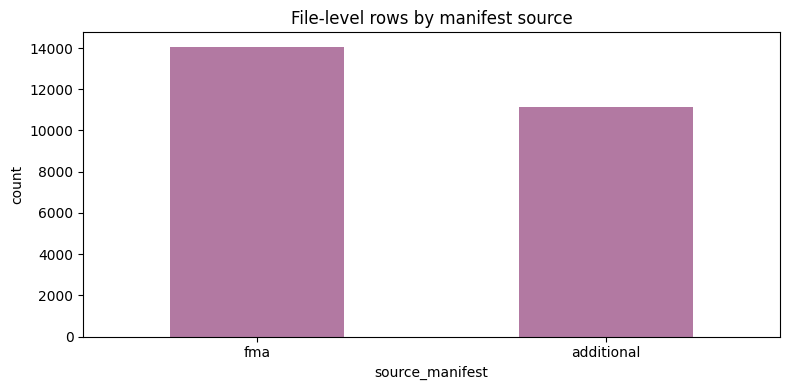

### Counts by Source

,source,count
0,fma-medium,14059
1,my-collection,7853
2,mtg-jamendo,2605
3,gtzan,700


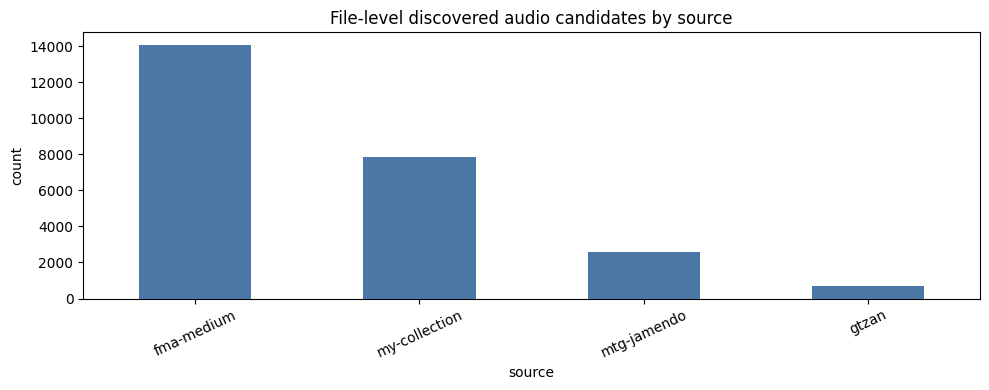

### Counts by Genre

,genre_top,count,proportion_pct,imbalance_ratio_vs_max
0,Rock,7013,27.81,1.000
1,Electronic,5314,21.07,1.320
2,Hip-Hop,1984,7.87,3.535
3,Classical,1638,6.50,4.281
4,Jazz,1524,6.04,4.602
5,Pop,1485,5.89,4.723
6,Bolero,1469,5.83,4.774
7,Blues,1447,5.74,4.847
8,Speech,1218,4.83,5.758
9,Country,1120,4.44,6.262


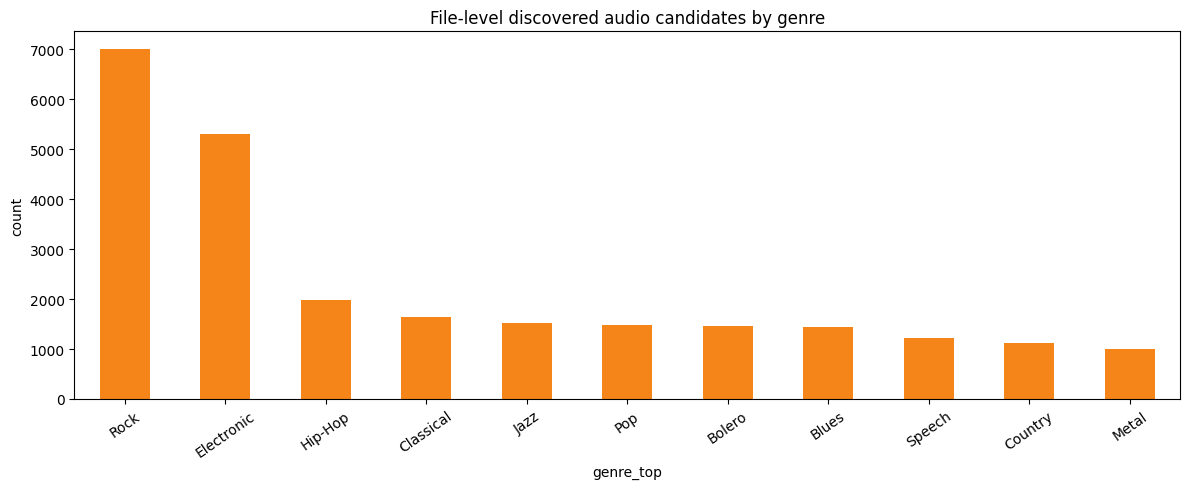

### Reason Code Breakdown

,reason_code,count
0,OK,25094
1,TOO_SHORT,104
2,AUDIO_READ_FAILED,19


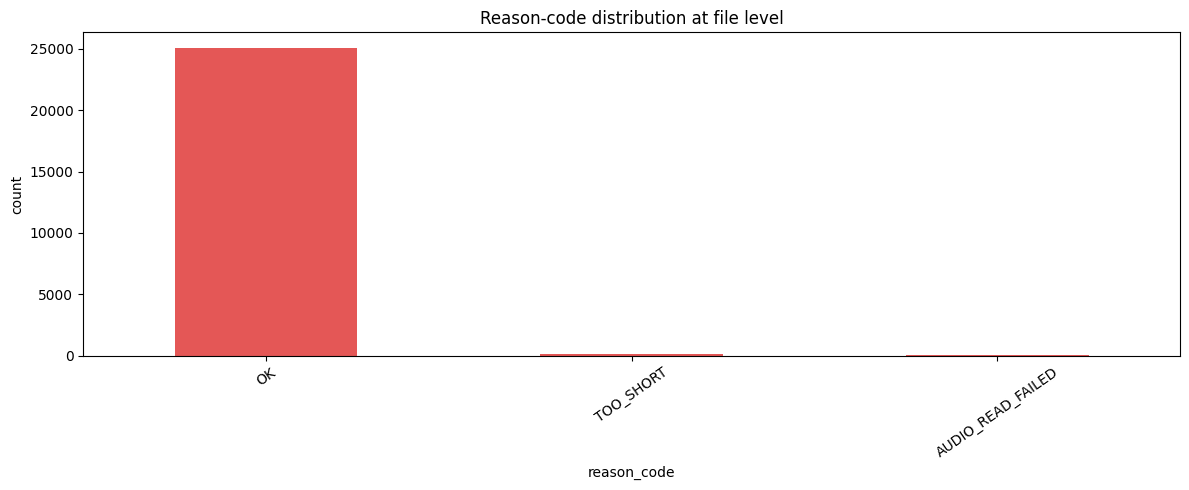

### Source by Reason Code

reason_code,AUDIO_READ_FAILED,OK,TOO_SHORT
source,,,
fma-medium,10,14047,2
gtzan,1,699,0
mtg-jamendo,0,2605,0
my-collection,8,7743,102


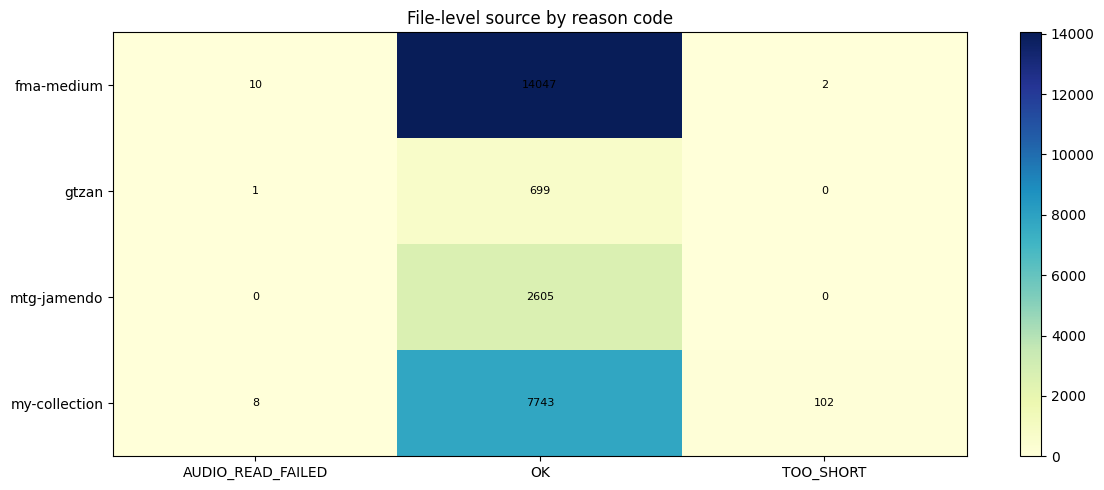

### Sampling Eligibility

,sampling_eligible,count
0,True,25094
1,False,123


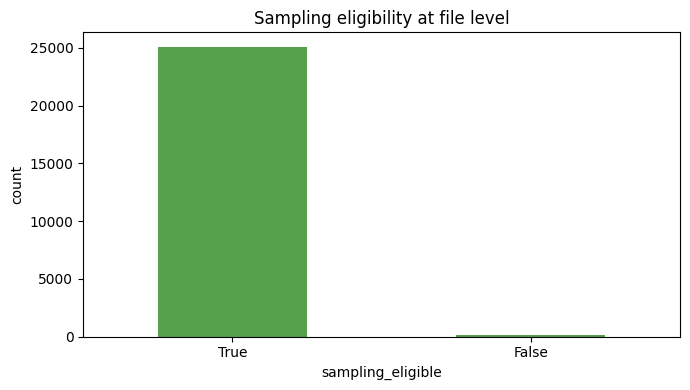

### Duration Summary

,count,mean,std,min,25%,50%,75%,max,missing_pct
actual_duration_s,25198.0,30.287718,2.004262,0.0,29.988571,30.014694,31.0,31.0,0.08
duration_s,25198.0,30.288475,2.003807,0.0,30.000000,30.000000,31.0,31.0,0.08


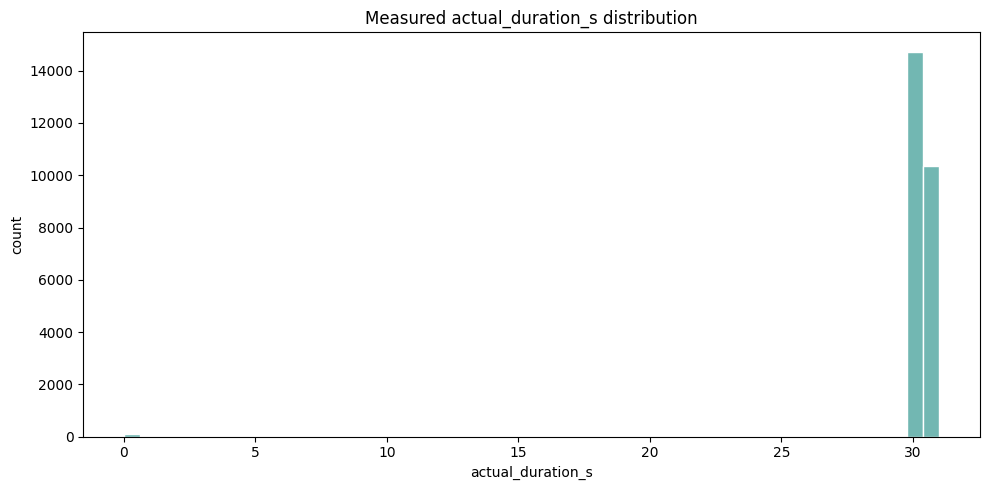

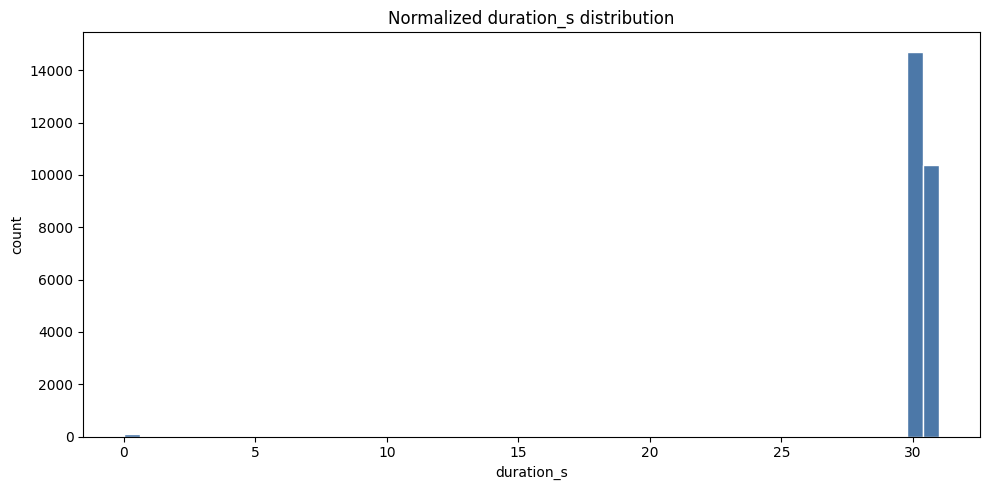

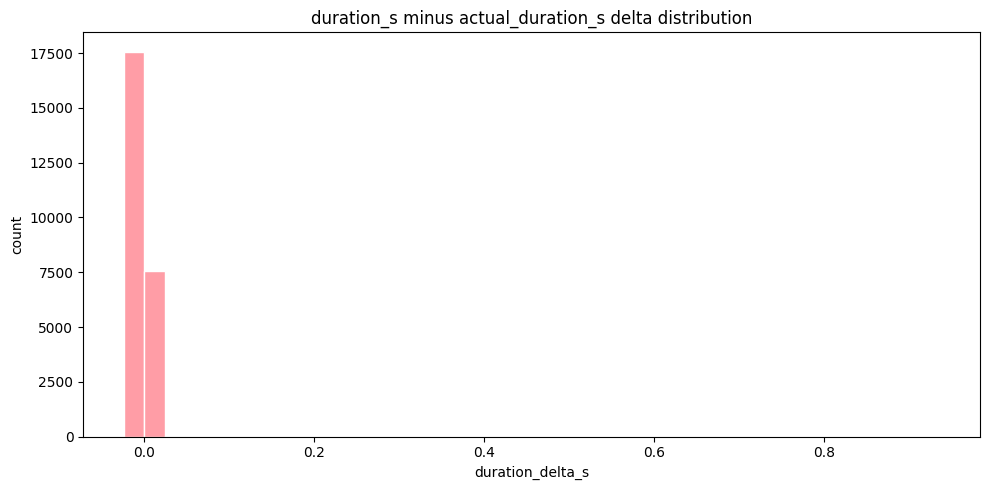

In [27]:
file_level_summary = pd.DataFrame([
    {'metric': 'total_discovered_audio_candidates', 'value': len(all_datasets_df)},
    {'metric': 'audio_exists_true', 'value': int(all_datasets_df['audio_exists'].fillna(False).sum())},
    {'metric': 'reason_code_OK', 'value': int((all_datasets_df['reason_code'] == 'OK').sum())},
    {'metric': 'sampling_eligible_true', 'value': int(all_datasets_df['sampling_eligible'].fillna(False).sum())},
    {'metric': 'unique_sources', 'value': all_datasets_df['source'].nunique(dropna=True)},
    {'metric': 'unique_genres', 'value': all_datasets_df['genre_top'].nunique(dropna=True)},
])
display(file_level_summary)

source_manifest_counts = all_datasets_df['_source_manifest'].value_counts()
source_counts = all_datasets_df['source'].value_counts()
genre_counts = all_datasets_df['genre_top'].value_counts()
reason_counts = all_datasets_df['reason_code'].value_counts()
eligibility_counts = all_datasets_df['sampling_eligible'].astype(str).value_counts()
source_reason_table = pd.crosstab(all_datasets_df['source'], all_datasets_df['reason_code'])

display(Markdown('### Counts by Manifest Source'))
display(source_manifest_counts.rename_axis('source_manifest').reset_index(name='count'))
plot_bar(source_manifest_counts, title='File-level rows by manifest source', xlabel='source_manifest', rotation=0, figsize=(8, 4), color='#B279A2')

display(Markdown('### Counts by Source'))
display(source_counts.rename_axis('source').reset_index(name='count'))
plot_bar(source_counts, title='File-level discovered audio candidates by source', xlabel='source', rotation=25, figsize=(10, 4))

display(Markdown('### Counts by Genre'))
display(imbalance_table(all_datasets_df['genre_top'], name='genre_top'))
plot_bar(genre_counts, title='File-level discovered audio candidates by genre', xlabel='genre_top', rotation=35, figsize=(12, 5), color='#F58518')

display(Markdown('### Reason Code Breakdown'))
display(reason_counts.rename_axis('reason_code').reset_index(name='count'))
plot_bar(reason_counts, title='Reason-code distribution at file level', xlabel='reason_code', rotation=35, figsize=(12, 5), color='#E45756')

display(Markdown('### Source by Reason Code'))
display(source_reason_table)
plot_heatmap(source_reason_table.astype(float), title='File-level source by reason code', figsize=(12, 5), fmt='.0f')

display(Markdown('### Sampling Eligibility'))
display(eligibility_counts.rename_axis('sampling_eligible').reset_index(name='count'))
plot_bar(eligibility_counts, title='Sampling eligibility at file level', xlabel='sampling_eligible', rotation=0, figsize=(7, 4), color='#54A24B')

duration_summary = all_datasets_df[['actual_duration_s', 'duration_s']].describe().T
duration_summary['missing_pct'] = all_datasets_df[['actual_duration_s', 'duration_s']].isna().mean().mul(100).round(2)
display(Markdown('### Duration Summary'))
display(duration_summary)

duration_analysis_df = all_datasets_df.copy()
duration_analysis_df['duration_delta_s'] = duration_analysis_df['duration_s'] - duration_analysis_df['actual_duration_s']
plot_hist(duration_analysis_df['actual_duration_s'], title='Measured actual_duration_s distribution', bins=50)
plot_hist(duration_analysis_df['duration_s'], title='Normalized duration_s distribution', bins=50, color='#4C78A8')
plot_hist(duration_analysis_df['duration_delta_s'], title='duration_s minus actual_duration_s delta distribution', bins=40, color='#FF9DA6')

## File-Level Discovered Audio Duration

This section aggregates discovered file-level audio duration, preferring `actual_duration_s` and falling back to `duration_s` when measured duration is missing.

,metric,value
0,rows_with_usable_duration,25096.00
1,total_discovered_duration_hours,212.00
2,mean_discovered_duration_minutes,0.51
3,median_discovered_duration_minutes,0.50


### Audio Duration by Source

,source,duration_hours
0,fma-medium,117.061247
1,my-collection,66.673907
2,mtg-jamendo,22.431713
3,gtzan,5.830334


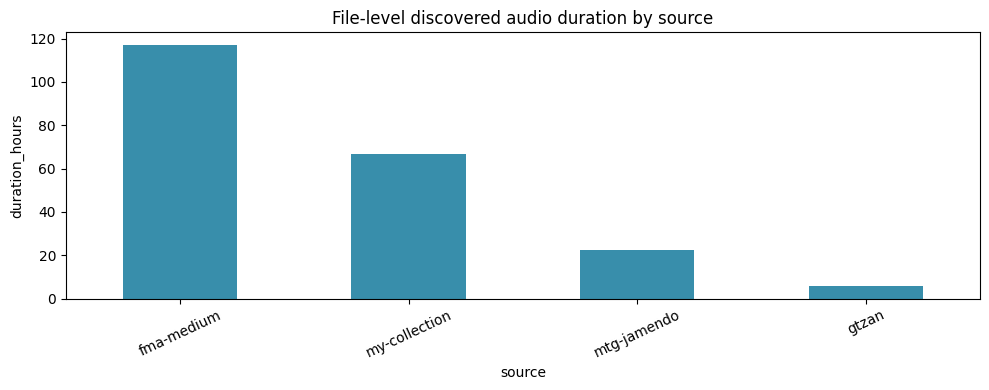

### Audio Duration by Genre

,genre_top,duration_hours
0,Rock,57.779530
1,Electronic,44.267131
2,Hip-Hop,16.679190
3,Classical,13.906062
4,Jazz,12.981456
5,Pop,12.708022
6,Bolero,12.589444
7,Blues,12.403669
8,Speech,10.488333
9,Country,9.567851


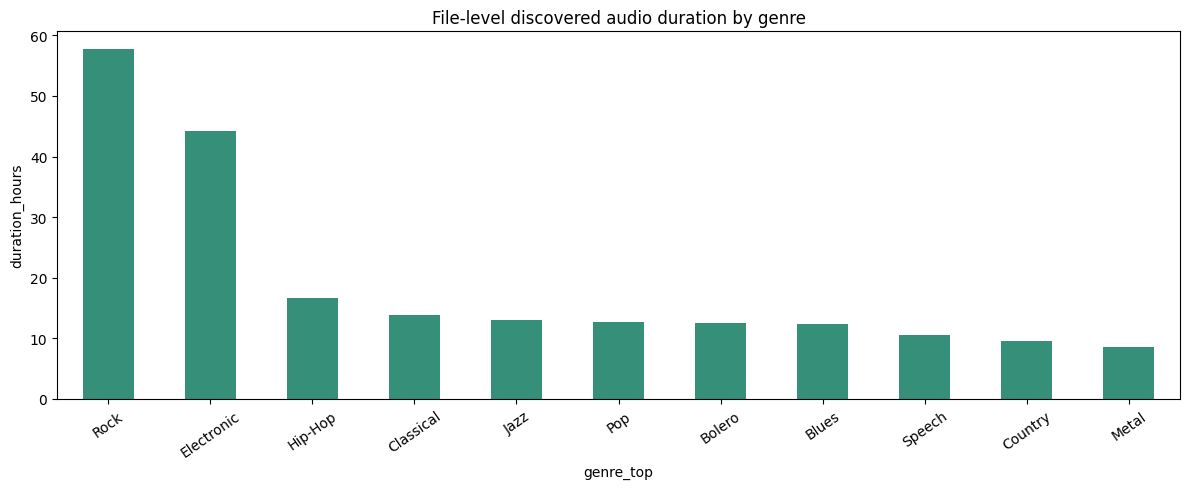

In [28]:
duration_audit_df = all_datasets_df.copy()
duration_audit_df['duration_for_aggregation_s'] = pd.to_numeric(
    duration_audit_df['actual_duration_s'],
    errors='coerce',
)
duration_audit_df['duration_for_aggregation_s'] = duration_audit_df['duration_for_aggregation_s'].fillna(
    pd.to_numeric(duration_audit_df['duration_s'], errors='coerce')
)
duration_audit_df = duration_audit_df[
    duration_audit_df['duration_for_aggregation_s'].notna()
    & (duration_audit_df['duration_for_aggregation_s'] > 0)
].copy()
duration_audit_df['duration_hours'] = duration_audit_df['duration_for_aggregation_s'] / 3600.0

display(Markdown('## File-Level Discovered Audio Duration'))
display(Markdown(
    'This section aggregates discovered file-level audio duration, preferring `actual_duration_s` and falling back to `duration_s` when measured duration is missing.'
) )

if duration_audit_df.empty:
    print('No valid positive audio durations were found in the file-level manifests.')
else:
    duration_metric_rows = pd.DataFrame([
        {'metric': 'rows_with_usable_duration', 'value': len(duration_audit_df)},
        {'metric': 'total_discovered_duration_hours', 'value': round(duration_audit_df['duration_hours'].sum(), 2)},
        {'metric': 'mean_discovered_duration_minutes', 'value': round(duration_audit_df['duration_for_aggregation_s'].mean() / 60.0, 2)},
        {'metric': 'median_discovered_duration_minutes', 'value': round(duration_audit_df['duration_for_aggregation_s'].median() / 60.0, 2)},
    ])
    display(duration_metric_rows)

    duration_by_source = duration_audit_df.groupby('source')['duration_hours'].sum().sort_values(ascending=False)
    duration_by_genre = duration_audit_df.groupby('genre_top')['duration_hours'].sum().sort_values(ascending=False)

    display(Markdown('### Audio Duration by Source'))
    display(duration_by_source.rename_axis('source').reset_index(name='duration_hours'))
    plot_bar(
        duration_by_source,
        title='File-level discovered audio duration by source',
        xlabel='source',
        ylabel='duration_hours',
        rotation=25,
        figsize=(10, 4),
        color="#388EAB",
    )


    display(Markdown('### Audio Duration by Genre'))
    display(duration_by_genre.rename_axis('genre_top').reset_index(name='duration_hours'))
    plot_bar(
        duration_by_genre,
        title='File-level discovered audio duration by genre',
        xlabel='genre_top',
        ylabel='duration_hours',
        rotation=35,
        figsize=(12, 5),
        color="#368F79",
    )

## Segment Expansion and Final Split Audits

This section connects the two source-specific stage 1 sample manifests to the stage 2 final manifest that downstream feature extraction and training actually consume.

The main questions are:

- how many segments each source audio emitted in stage 1
- how many segments survived into the final manifest
- whether final split assignment preserved source-audio grouping
- whether additional-source contribution is visible and close to the configured target

,metric,value
0,all_stage1_sample_rows,50186.0
1,final_sample_rows,24973.0
2,unique_stage1_artifacts,25094.0
3,unique_final_artifacts,12487.0
4,mean_emitted_segments_per_audio,2.0
5,mean_selected_segments_per_audio,2.0


### Stage 1 Segment Rows by Manifest

,source_manifest,count
0,fma,28093
1,additional,22093


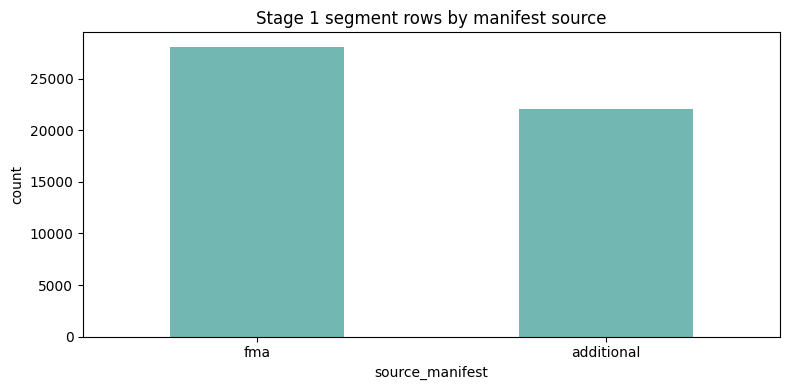

### Stage 1 Segment Rows by Source

,source,count
0,fma-medium,28093
1,my-collection,15485
2,mtg-jamendo,5210
3,gtzan,1398


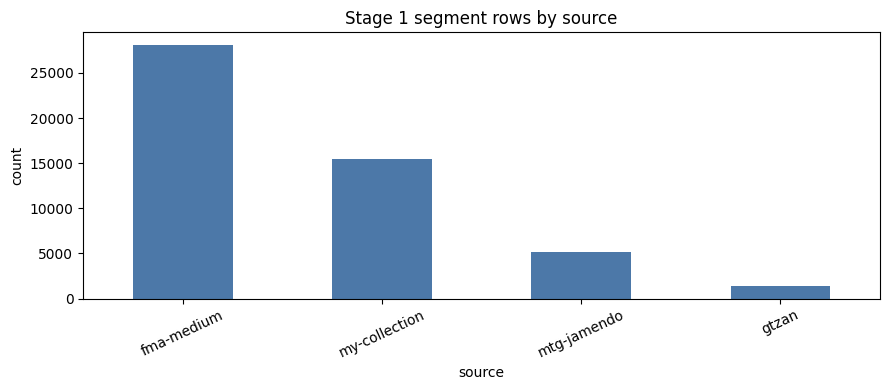

### Stage 1 Segment Rows by Genre

,genre_top,count,proportion_pct,imbalance_ratio_vs_max
0,Rock,13812,27.52,1.000
1,Electronic,10624,21.17,1.300
2,Hip-Hop,3956,7.88,3.491
3,Classical,3276,6.53,4.216
4,Jazz,3046,6.07,4.534
5,Pop,2970,5.92,4.651
6,Bolero,2924,5.83,4.724
7,Blues,2892,5.76,4.776
8,Speech,2436,4.85,5.670
9,Country,2240,4.46,6.166


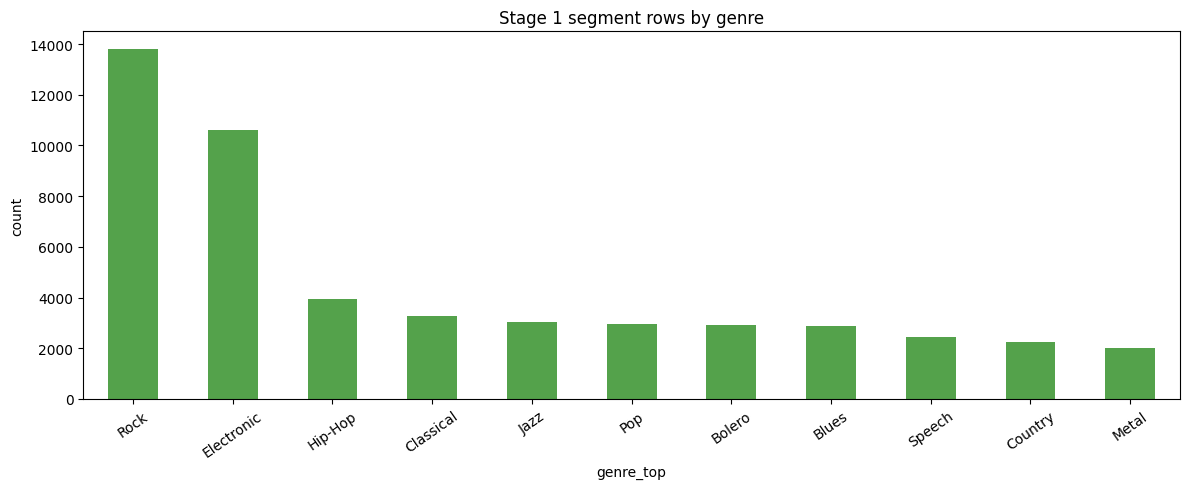

### Final Split Counts

,final_split,count
0,training,17474
1,test,3751
2,validation,3748


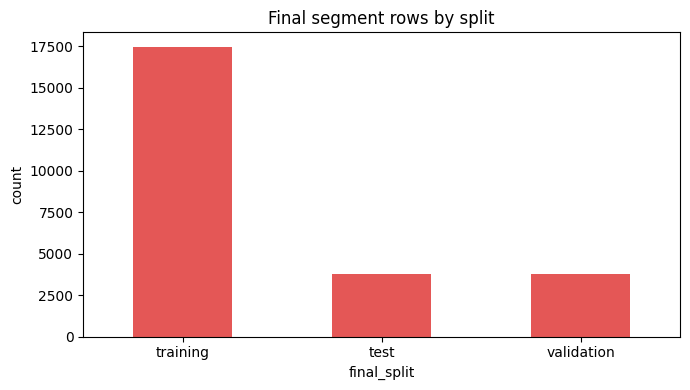

### Final Segment Rows by Genre

,genre_top,count,proportion_pct,imbalance_ratio_vs_max
0,Classical,2304,9.23,1.000
1,Jazz,2304,9.23,1.000
2,Rock,2303,9.22,1.000
3,Blues,2302,9.22,1.001
4,Bolero,2302,9.22,1.001
5,Electronic,2302,9.22,1.001
6,Hip-Hop,2302,9.22,1.001
7,Pop,2302,9.22,1.001
8,Speech,2302,9.22,1.001
9,Country,2240,8.97,1.029


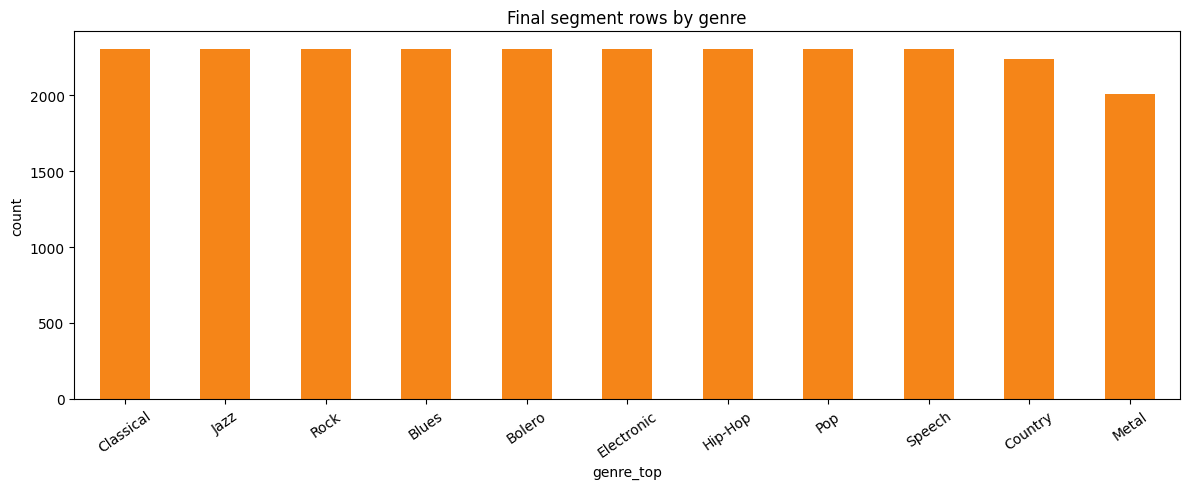

### Final Counts by Genre and Split

final_split,test,training,validation
genre_top,,,
Blues,346,1610,346
Bolero,346,1610,346
Classical,346,1612,346
Country,336,1570,334
Electronic,346,1610,346
Hip-Hop,346,1610,346
Jazz,346,1612,346
Metal,302,1408,300
Pop,346,1610,346


final_split,test,training,validation
genre_top,,,
Blues,15.03,69.94,15.03
Bolero,15.03,69.94,15.03
Classical,15.02,69.97,15.02
Country,15.00,70.09,14.91
Electronic,15.03,69.94,15.03
Hip-Hop,15.03,69.94,15.03
Jazz,15.02,69.97,15.02
Metal,15.02,70.05,14.93
Pop,15.03,69.94,15.03


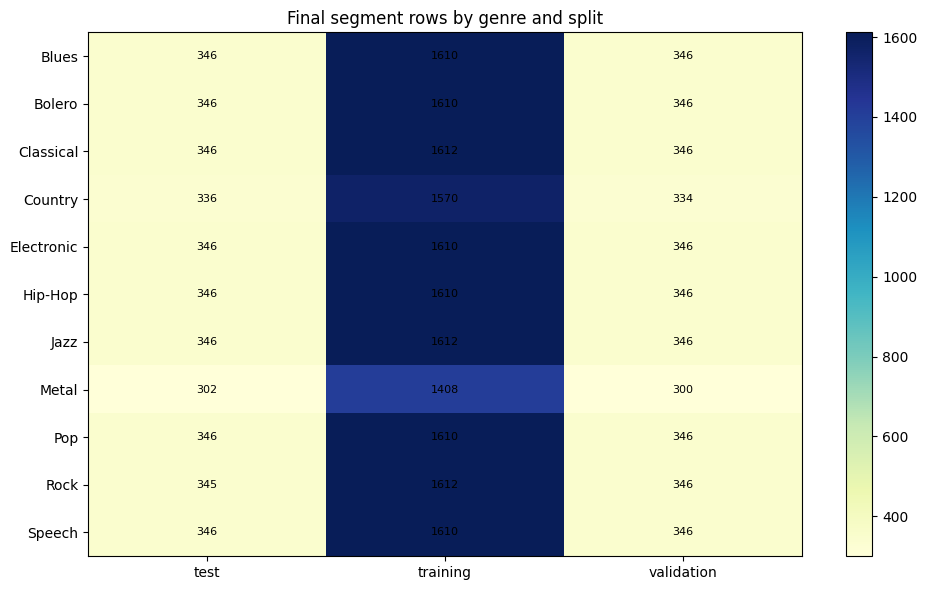

### Retention by Source

,stage1_artifacts,stage1_segments,final_segments,retained_ratio_pct
source,,,,
fma-medium,14047,28093,5990,21.32
gtzan,699,1398,1220,87.27
mtg-jamendo,2605,5210,4420,84.84
my-collection,7743,15485,13343,86.17


### Leakage-Safety Check

,metric,value
0,artifacts_in_multiple_final_splits,0


Leakage check passed: no source-audio artifact appears in more than one final split.


### Additional-Source Contribution

,metric,value
0,target_additional_contribution_pct,70.00
1,actual_additional_contribution_pct,76.01
2,actual_fma_contribution_pct,23.99


source_family,fma,additional_datasets
genre_top,,
Blues,148,2154
Bolero,0,2302
Classical,692,1612
Country,356,1884
Electronic,2302,0
Hip-Hop,736,1566
Jazz,692,1612
Metal,0,2010
Pop,372,1930


source_family,fma,additional_datasets,target_additional_pct,gap_vs_target_pct
genre_top,,,,
Blues,6.43,93.57,70.0,23.57
Bolero,0.00,100.00,70.0,30.00
Classical,30.03,69.97,70.0,-0.03
Country,15.89,84.11,70.0,14.11
Electronic,100.00,0.00,70.0,-70.00
Hip-Hop,31.97,68.03,70.0,-1.97
Jazz,30.03,69.97,70.0,-0.03
Metal,0.00,100.00,70.0,30.00
Pop,16.16,83.84,70.0,13.84


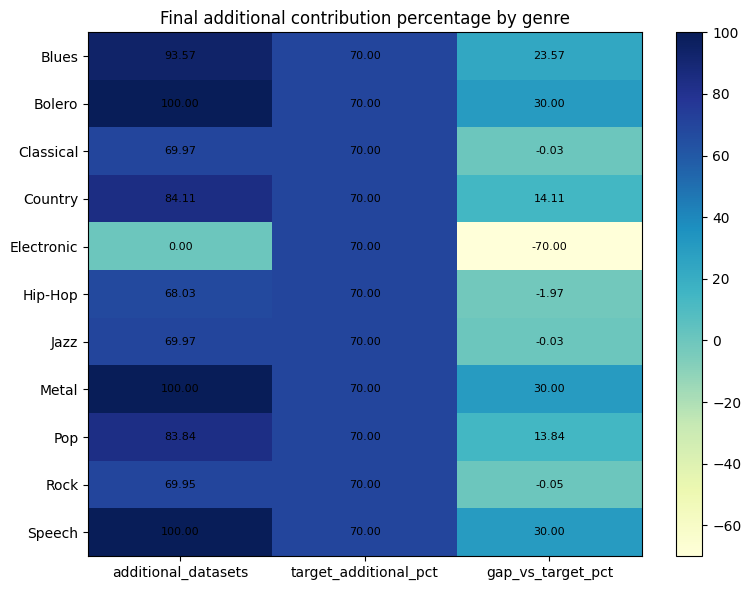

In [34]:
all_samples_audio_summary = all_samples_df.groupby('artifact_id').agg(
    source=('source', 'first'),
    genre_top=('genre_top', 'first'),
    duration_s=('duration_s', 'first'),
    actual_duration_s=('actual_duration_s', 'first'),
    total_segments_from_audio=('total_segments_from_audio', 'first'),
    emitted_segments=('sample_id', 'size'),
).reset_index()

final_samples_audio_level = final_samples_df.copy()
final_samples_audio_level['artifact_id'] = final_samples_audio_level['sample_id'].map(artifact_id_from_sample_id)
final_samples_audio_summary = final_samples_audio_level.groupby('artifact_id').agg(
    source=('source', 'first'),
    genre_top=('genre_top', 'first'),
    final_split=('final_split', 'first'),
    selected_segments=('sample_id', 'size'),
).reset_index()

segment_transition_df = all_samples_audio_summary.merge(
    final_samples_audio_summary[['artifact_id', 'final_split', 'selected_segments']],
    on='artifact_id',
    how='left',
)
segment_transition_df['selected_segments'] = segment_transition_df['selected_segments'].fillna(0).astype(int)
segment_transition_df['retained_ratio_pct'] = (segment_transition_df['selected_segments'] / segment_transition_df['emitted_segments']).mul(100).round(2)

transition_summary = pd.DataFrame([
    {'metric': 'all_stage1_sample_rows', 'value': len(all_samples_df)},
    {'metric': 'final_sample_rows', 'value': len(final_samples_df)},
    {'metric': 'unique_stage1_artifacts', 'value': len(all_samples_audio_summary)},
    {'metric': 'unique_final_artifacts', 'value': len(final_samples_audio_summary)},
    {'metric': 'mean_emitted_segments_per_audio', 'value': round(all_samples_audio_summary['emitted_segments'].mean(), 2)},
    {'metric': 'mean_selected_segments_per_audio', 'value': round(final_samples_audio_summary['selected_segments'].mean(), 2)},
])
display(transition_summary)

stage1_segments_by_manifest = all_samples_df['_source_manifest'].value_counts()
stage1_segments_by_source = all_samples_df['source'].value_counts()
stage1_segments_by_genre = all_samples_df['genre_top'].value_counts()
final_split_counts = final_samples_df['final_split'].value_counts()
final_genre_counts = final_samples_df['genre_top'].value_counts()
genre_split_table = pd.crosstab(final_samples_df['genre_top'], final_samples_df['final_split'])
genre_split_pct = genre_split_table.div(genre_split_table.sum(axis=1), axis=0).mul(100).round(2)

retention_by_source = segment_transition_df.groupby('source').agg(
    stage1_artifacts=('artifact_id', 'size'),
    stage1_segments=('emitted_segments', 'sum'),
    final_segments=('selected_segments', 'sum'),
)
retention_by_source['retained_ratio_pct'] = (retention_by_source['final_segments'] / retention_by_source['stage1_segments']).mul(100).round(2)

display(Markdown('### Stage 1 Segment Rows by Manifest'))
display(stage1_segments_by_manifest.rename_axis('source_manifest').reset_index(name='count'))
plot_bar(stage1_segments_by_manifest, title='Stage 1 segment rows by manifest source', xlabel='source_manifest', rotation=0, figsize=(8, 4), color='#72B7B2')

display(Markdown('### Stage 1 Segment Rows by Source'))
display(stage1_segments_by_source.rename_axis('source').reset_index(name='count'))
plot_bar(stage1_segments_by_source, title='Stage 1 segment rows by source', xlabel='source', rotation=25, figsize=(9, 4), color='#4C78A8')

display(Markdown('### Stage 1 Segment Rows by Genre'))
display(imbalance_table(all_samples_df['genre_top'], name='genre_top'))
plot_bar(stage1_segments_by_genre, title='Stage 1 segment rows by genre', xlabel='genre_top', rotation=35, figsize=(12, 5), color='#54A24B')

display(Markdown('### Final Split Counts'))
display(final_split_counts.rename_axis('final_split').reset_index(name='count'))
plot_bar(final_split_counts, title='Final segment rows by split', xlabel='final_split', rotation=0, figsize=(7, 4), color='#E45756')

display(Markdown('### Final Segment Rows by Genre'))
display(imbalance_table(final_samples_df['genre_top'], name='genre_top'))
plot_bar(final_genre_counts, title='Final segment rows by genre', xlabel='genre_top', rotation=35, figsize=(12, 5), color='#F58518')

display(Markdown('### Final Counts by Genre and Split'))
display(genre_split_table)
display(genre_split_pct)
plot_heatmap(genre_split_table.astype(float), title='Final segment rows by genre and split', figsize=(10, 6), fmt='.0f')

display(Markdown('### Retention by Source'))
display(retention_by_source)

artifact_split_counts = final_samples_audio_level.groupby('artifact_id')['final_split'].nunique()
leakage_artifacts = artifact_split_counts[artifact_split_counts > 1]
leakage_count = int(leakage_artifacts.shape[0])
display(Markdown('### Leakage-Safety Check'))
display(pd.DataFrame([{'metric': 'artifacts_in_multiple_final_splits', 'value': leakage_count}]))
if leakage_count == 0:
    print('Leakage check passed: no source-audio artifact appears in more than one final split.')
else:
    display(leakage_artifacts.rename('num_splits').reset_index())

final_samples_source_view = final_samples_df.copy()
final_samples_source_view['source_family'] = np.where(
    final_samples_source_view['source'].astype(str).str.casefold().str.startswith('fma'),
    'fma',
    'additional_datasets',
)
additional_ratio_target_pct = round(float(sampling_settings.get('additional_samples_contribution_ratio_expected_each_genre', 0.0)) * 100, 2)
overall_source_counts = final_samples_source_view['source_family'].value_counts().reindex(['fma', 'additional_datasets'], fill_value=0)
overall_additional_share_pct = round(overall_source_counts.get('additional_datasets', 0) / max(len(final_samples_source_view), 1) * 100, 2)
genre_source_table = pd.crosstab(final_samples_source_view['genre_top'], final_samples_source_view['source_family']).reindex(columns=['fma', 'additional_datasets'], fill_value=0)
genre_source_pct = genre_source_table.div(genre_source_table.sum(axis=1), axis=0).mul(100).round(2)
genre_source_pct['target_additional_pct'] = additional_ratio_target_pct
genre_source_pct['gap_vs_target_pct'] = (genre_source_pct['additional_datasets'] - genre_source_pct['target_additional_pct']).round(2)

display(Markdown('### Additional-Source Contribution'))
display(pd.DataFrame([
    {'metric': 'target_additional_contribution_pct', 'value': additional_ratio_target_pct},
    {'metric': 'actual_additional_contribution_pct', 'value': overall_additional_share_pct},
    {'metric': 'actual_fma_contribution_pct', 'value': round(100 - overall_additional_share_pct, 2)},
]))
display(genre_source_table)
display(genre_source_pct)
plot_heatmap(genre_source_pct[['additional_datasets', 'target_additional_pct', 'gap_vs_target_pct']].astype(float), title='Final additional contribution percentage by genre', figsize=(8, 6), fmt='.2f')

## Final Manifest Core Statistics

This section focuses on the stage 2 output itself: the selected segment-level final manifest that downstream preprocessing is expected to consume.

The main goals are to quantify:

- headline size and effective audio volume
- balance quality against configured per-genre targets
- split fidelity against the configured train/validation/test ratio
- off-target genre drift relative to `settings.json`
- source concentration and additional-source contribution gaps

### Final Manifest KPI Table

,metric,value
0,final_manifest_rows,24973.0000
1,final_manifest_effective_hours,104.0500
2,configured_target_genre_count,10.0000
3,observed_final_genre_count,11.0000
4,unique_sources_in_final_manifest,4.0000
5,estimated_unique_source_audios,12487.0000
6,genre_max_min_ratio,1.1463
7,genre_count_cv_pct,3.7100
8,off_target_rows,2302.0000
9,off_target_row_pct,9.2180


### Target vs Actual Rows by Genre

,genre_top,actual_rows,target_rows,gap_vs_target,actual_pct_of_target
0,Electronic,2302,0,2302,NaN
1,Classical,2304,3200,-896,72.00
2,Jazz,2304,3200,-896,72.00
3,Rock,2303,3200,-897,71.97
4,Blues,2302,3200,-898,71.94
5,Bolero,2302,3200,-898,71.94
6,Hip-Hop,2302,3200,-898,71.94
7,Pop,2302,3200,-898,71.94
8,Speech,2302,3200,-898,71.94
9,Country,2240,3200,-960,70.00


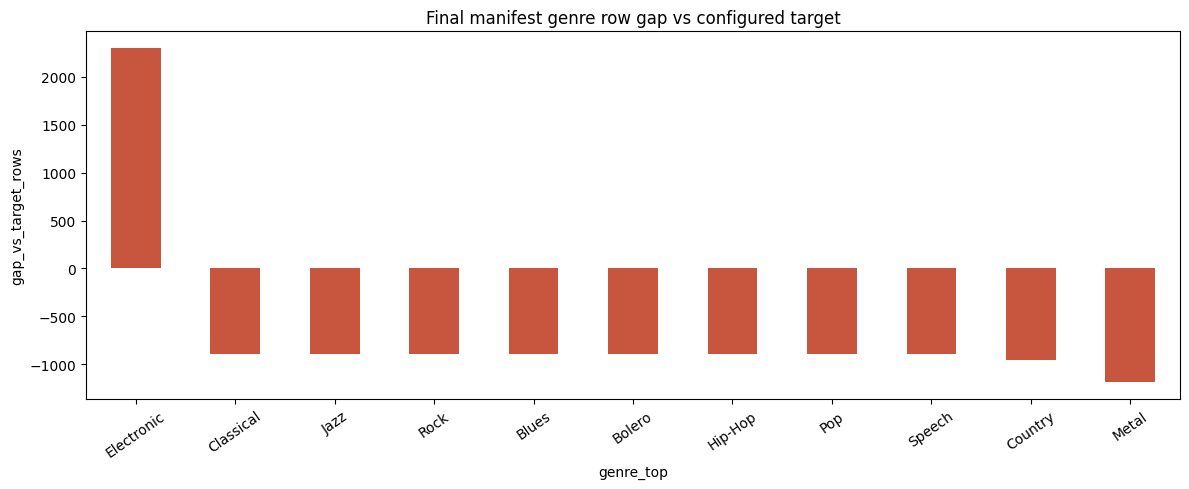

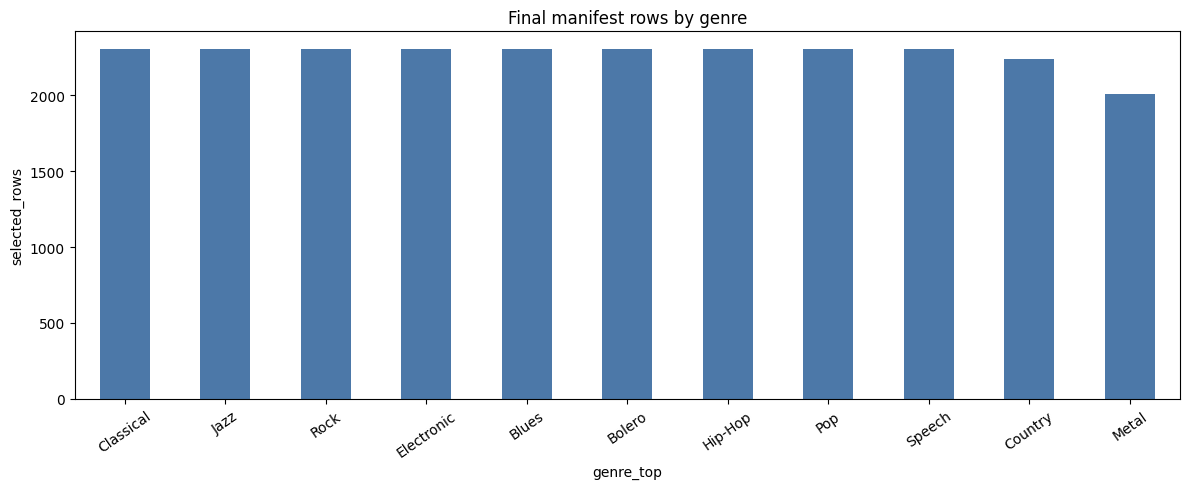

### Split Fidelity Metrics

,metric,value
0,configured_training_pct,70.00
1,configured_validation_pct,15.00
2,configured_test_pct,15.00
3,observed_training_pct,69.97
4,observed_validation_pct,15.01
5,observed_test_pct,15.02
6,max_abs_training_gap_pct_points,0.09
7,max_abs_validation_gap_pct_points,0.09
8,max_abs_test_gap_pct_points,0.03


final_split,training,validation,test
genre_top,,,
Blues,69.94,15.03,15.03
Bolero,69.94,15.03,15.03
Classical,69.97,15.02,15.02
Country,70.09,14.91,15.00
Electronic,69.94,15.03,15.03
Hip-Hop,69.94,15.03,15.03
Jazz,69.97,15.02,15.02
Metal,70.05,14.93,15.02
Pop,69.94,15.03,15.03


,training_gap_pct,validation_gap_pct,test_gap_pct
genre_top,,,
Blues,-0.06,0.03,0.03
Bolero,-0.06,0.03,0.03
Classical,-0.03,0.02,0.02
Country,0.09,-0.09,-0.00
Electronic,-0.06,0.03,0.03
Hip-Hop,-0.06,0.03,0.03
Jazz,-0.03,0.02,0.02
Metal,0.05,-0.07,0.02
Pop,-0.06,0.03,0.03


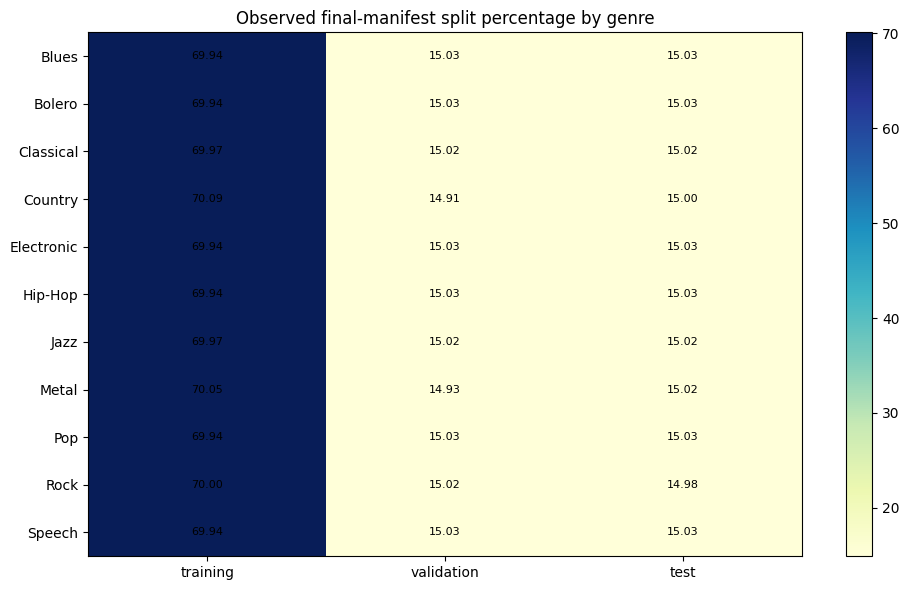

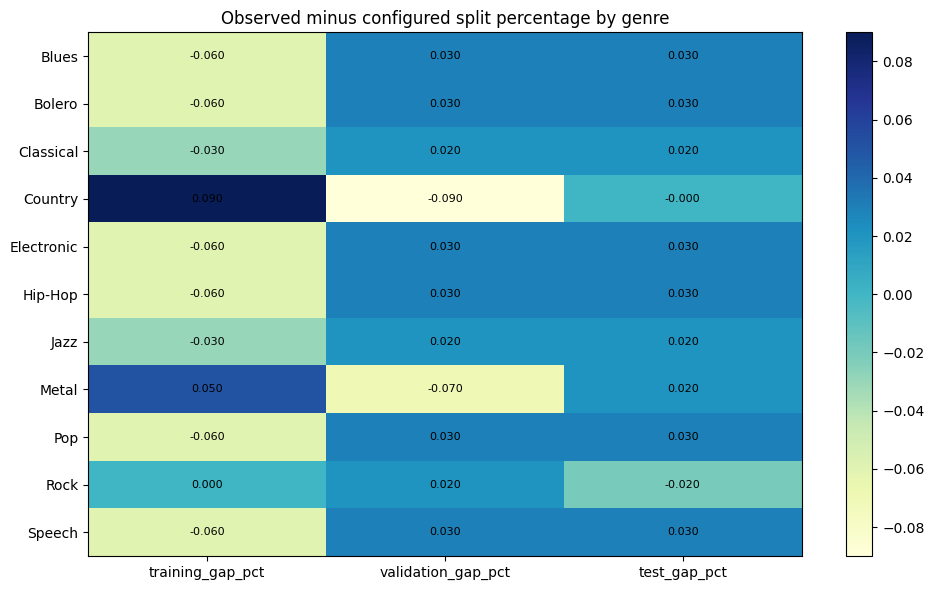

### Off-Target Genre Diagnostics

,metric,value
0,off_target_rows,2302.000
1,off_target_row_pct,9.218
2,off_target_unique_genres,1.000


,genre_top,count
0,Electronic,2302


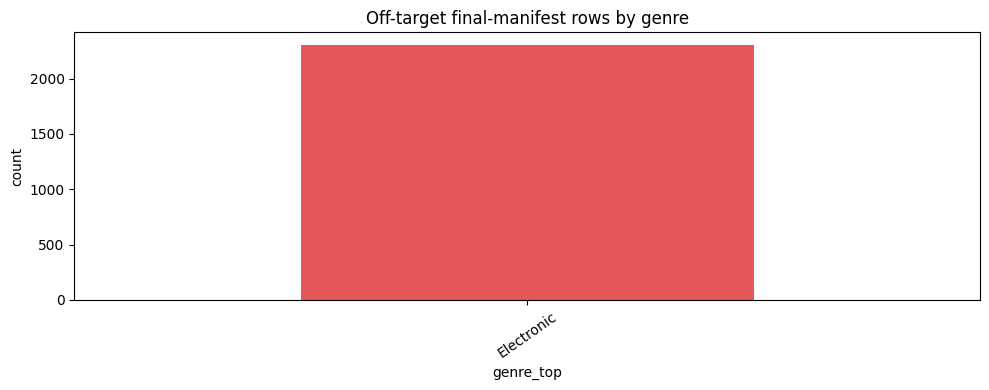

### Source Concentration

,source,count,share_pct
0,my-collection,13343,53.43
1,fma-medium,5990,23.99
2,mtg-jamendo,4420,17.70
3,gtzan,1220,4.89


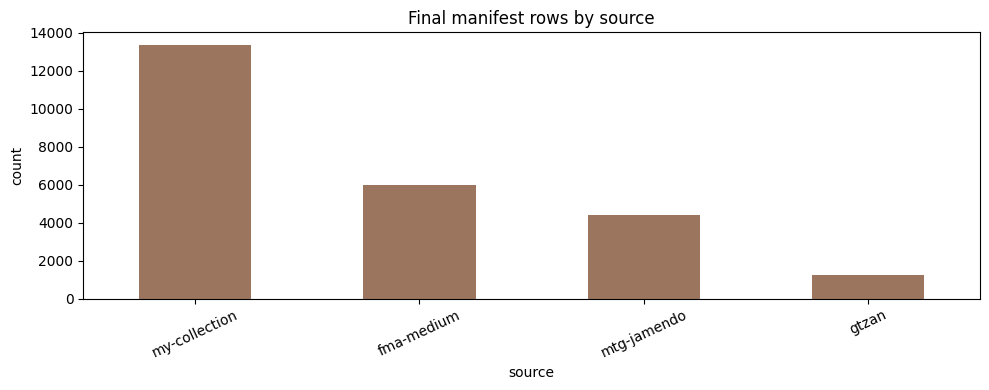

### Additional-Source Gap by Genre

source_family,fma,additional_datasets
genre_top,,
Blues,148,2154
Bolero,0,2302
Classical,692,1612
Country,356,1884
Electronic,2302,0
Hip-Hop,736,1566
Jazz,692,1612
Metal,0,2010
Pop,372,1930


source_family,fma,additional_datasets,target_additional_pct,gap_vs_target_pct
genre_top,,,,
Blues,6.43,93.57,70.0,23.57
Bolero,0.00,100.00,70.0,30.00
Classical,30.03,69.97,70.0,-0.03
Country,15.89,84.11,70.0,14.11
Electronic,100.00,0.00,70.0,-70.00
Hip-Hop,31.97,68.03,70.0,-1.97
Jazz,30.03,69.97,70.0,-0.03
Metal,0.00,100.00,70.0,30.00
Pop,16.16,83.84,70.0,13.84


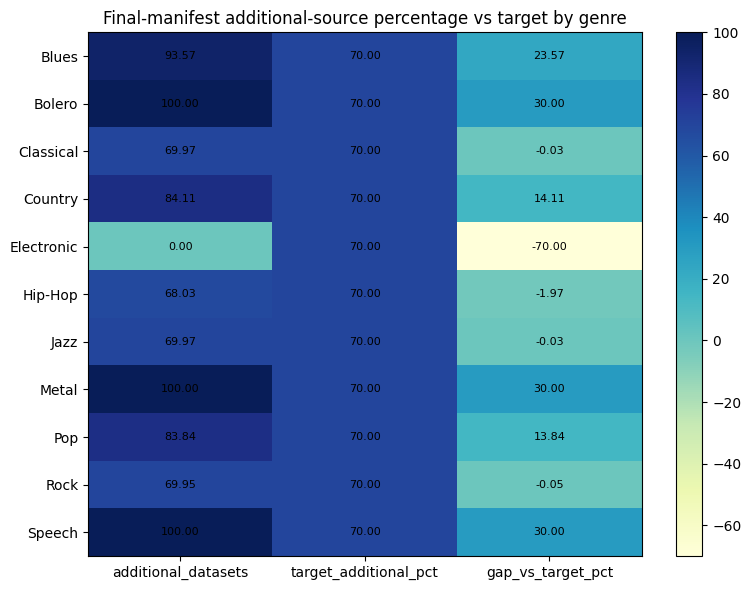

In [30]:
configured_target_genres_from_settings = [
    genre.strip()
    for genre in sampling_settings.get('target_genres', [])
    if isinstance(genre, str) and genre.strip()
 ]

expected_train_ratio = float(sampling_settings.get('train_n_val_test_split_ratio_each_genre', 0.7) or 0.7)
expected_val_ratio = (1.0 - expected_train_ratio) / 2.0
expected_test_ratio = expected_val_ratio
expected_target_per_genre = int(sampling_settings.get('number_of_samples_expected_each_genre', 0) or 0)
final_manifest_clip_hours = len(final_samples_df) * CONFIGURED_SAMPLE_LENGTH_SEC / 3600.0

final_manifest_genre_counts = final_samples_df['genre_top'].value_counts().sort_values(ascending=False)
final_manifest_source_counts = final_samples_df['source'].value_counts().sort_values(ascending=False)
final_manifest_estimated_artifacts = final_samples_df['sample_id'].map(artifact_id_from_sample_id).nunique()

off_target_final_samples_df = final_samples_df.loc[
    ~final_samples_df['genre_top'].isin(configured_target_genres_from_settings)
].copy()
off_target_genre_counts = off_target_final_samples_df['genre_top'].value_counts().sort_values(ascending=False)

genre_target_table = final_manifest_genre_counts.rename_axis('genre_top').reset_index(name='actual_rows')
genre_target_table['target_rows'] = genre_target_table['genre_top'].map(
    lambda genre: expected_target_per_genre if genre in configured_target_genres_from_settings else 0
)
genre_target_table['gap_vs_target'] = genre_target_table['actual_rows'] - genre_target_table['target_rows']
genre_target_table['actual_pct_of_target'] = np.where(
    genre_target_table['target_rows'] > 0,
    (genre_target_table['actual_rows'] / genre_target_table['target_rows'] * 100).round(2),
    np.nan,
 )
genre_target_table = genre_target_table.sort_values(['gap_vs_target', 'actual_rows'], ascending=[False, False]).reset_index(drop=True)

genre_balance_metrics = pd.DataFrame([
    {'metric': 'final_manifest_rows', 'value': len(final_samples_df)},
    {'metric': 'final_manifest_effective_hours', 'value': round(final_manifest_clip_hours, 2)},
    {'metric': 'configured_target_genre_count', 'value': len(configured_target_genres_from_settings)},
    {'metric': 'observed_final_genre_count', 'value': final_samples_df['genre_top'].nunique()},
    {'metric': 'unique_sources_in_final_manifest', 'value': final_samples_df['source'].nunique()},
    {'metric': 'estimated_unique_source_audios', 'value': final_manifest_estimated_artifacts},
    {'metric': 'genre_max_min_ratio', 'value': round(final_manifest_genre_counts.max() / max(final_manifest_genre_counts.min(), 1), 4)},
    {'metric': 'genre_count_cv_pct', 'value': round(final_manifest_genre_counts.std(ddof=0) / max(final_manifest_genre_counts.mean(), 1) * 100, 3)},
    {'metric': 'off_target_rows', 'value': len(off_target_final_samples_df)},
    {'metric': 'off_target_row_pct', 'value': round(len(off_target_final_samples_df) / max(len(final_samples_df), 1) * 100, 3)},
    {'metric': 'leakage_artifacts_gt_one_split', 'value': leakage_count},
])

genre_split_counts_core = pd.crosstab(final_samples_df['genre_top'], final_samples_df['final_split']).reindex(
    columns=['training', 'validation', 'test'],
    fill_value=0,
 )
genre_split_pct_core = genre_split_counts_core.div(genre_split_counts_core.sum(axis=1), axis=0).mul(100).round(2)
genre_split_target_pct_core = pd.DataFrame(
    {
        'training_target_pct': expected_train_ratio * 100,
        'validation_target_pct': expected_val_ratio * 100,
        'test_target_pct': expected_test_ratio * 100,
    },
    index=genre_split_pct_core.index,
 )
genre_split_gap_pct = pd.DataFrame(index=genre_split_pct_core.index)
genre_split_gap_pct['training_gap_pct'] = (genre_split_pct_core['training'] - expected_train_ratio * 100).round(3)
genre_split_gap_pct['validation_gap_pct'] = (genre_split_pct_core['validation'] - expected_val_ratio * 100).round(3)
genre_split_gap_pct['test_gap_pct'] = (genre_split_pct_core['test'] - expected_test_ratio * 100).round(3)

split_fidelity_metrics = pd.DataFrame([
    {'metric': 'configured_training_pct', 'value': round(expected_train_ratio * 100, 2)},
    {'metric': 'configured_validation_pct', 'value': round(expected_val_ratio * 100, 2)},
    {'metric': 'configured_test_pct', 'value': round(expected_test_ratio * 100, 2)},
    {'metric': 'observed_training_pct', 'value': round(final_samples_df['final_split'].eq('training').mean() * 100, 2)},
    {'metric': 'observed_validation_pct', 'value': round(final_samples_df['final_split'].eq('validation').mean() * 100, 2)},
    {'metric': 'observed_test_pct', 'value': round(final_samples_df['final_split'].eq('test').mean() * 100, 2)},
    {'metric': 'max_abs_training_gap_pct_points', 'value': float(genre_split_gap_pct['training_gap_pct'].abs().max())},
    {'metric': 'max_abs_validation_gap_pct_points', 'value': float(genre_split_gap_pct['validation_gap_pct'].abs().max())},
    {'metric': 'max_abs_test_gap_pct_points', 'value': float(genre_split_gap_pct['test_gap_pct'].abs().max())},
])

final_manifest_source_view_core = final_samples_df.copy()
final_manifest_source_view_core['source_family'] = np.where(
    final_manifest_source_view_core['source'].astype(str).str.casefold().str.startswith('fma'),
    'fma',
    'additional_datasets',
 )
source_share_table = final_manifest_source_counts.rename_axis('source').reset_index(name='count')
source_share_table['share_pct'] = (source_share_table['count'] / max(len(final_samples_df), 1) * 100).round(2)
source_family_by_genre = pd.crosstab(
    final_manifest_source_view_core['genre_top'],
    final_manifest_source_view_core['source_family'],
 ).reindex(columns=['fma', 'additional_datasets'], fill_value=0)
source_family_pct_by_genre = source_family_by_genre.div(source_family_by_genre.sum(axis=1), axis=0).mul(100).round(2)
source_family_pct_by_genre['target_additional_pct'] = additional_ratio_target_pct
source_family_pct_by_genre['gap_vs_target_pct'] = (
    source_family_pct_by_genre['additional_datasets'] - source_family_pct_by_genre['target_additional_pct']
).round(2)

display(Markdown('### Final Manifest KPI Table'))
display(genre_balance_metrics)

display(Markdown('### Target vs Actual Rows by Genre'))
display(genre_target_table)
plot_bar(
    genre_target_table.set_index('genre_top')['gap_vs_target'],
    title='Final manifest genre row gap vs configured target',
    xlabel='genre_top',
    ylabel='gap_vs_target_rows',
    rotation=35,
    figsize=(12, 5),
    color='#C8553D',
)

plot_bar(
    genre_target_table.set_index('genre_top')['actual_rows'],
    title='Final manifest rows by genre',
    xlabel='genre_top',
    ylabel='selected_rows',
    rotation=35,
    figsize=(12, 5),
    color='#4C78A8',
)

display(Markdown('### Split Fidelity Metrics'))
display(split_fidelity_metrics)
display(genre_split_pct_core)
display(genre_split_gap_pct)
plot_heatmap(
    genre_split_pct_core.astype(float),
    title='Observed final-manifest split percentage by genre',
    figsize=(10, 6),
    fmt='.2f',
)
plot_heatmap(
    genre_split_gap_pct.astype(float),
    title='Observed minus configured split percentage by genre',
    figsize=(10, 6),
    fmt='.3f',
)

display(Markdown('### Off-Target Genre Diagnostics'))
if off_target_final_samples_df.empty:
    print('No off-target genres were found in manifest_final_samples.parquet relative to settings.json target_genres.')
else:
    off_target_summary = pd.DataFrame([
        {'metric': 'off_target_rows', 'value': len(off_target_final_samples_df)},
        {'metric': 'off_target_row_pct', 'value': round(len(off_target_final_samples_df) / max(len(final_samples_df), 1) * 100, 3)},
        {'metric': 'off_target_unique_genres', 'value': off_target_final_samples_df['genre_top'].nunique()},
    ])
    display(off_target_summary)
    display(off_target_genre_counts.rename_axis('genre_top').reset_index(name='count'))
    plot_bar(
        off_target_genre_counts,
        title='Off-target final-manifest rows by genre',
        xlabel='genre_top',
        ylabel='count',
        rotation=35,
        figsize=(10, 4),
        color='#E45756',
    )

display(Markdown('### Source Concentration'))
display(source_share_table)
plot_bar(
    final_manifest_source_counts,
    title='Final manifest rows by source',
    xlabel='source',
    ylabel='count',
    rotation=25,
    figsize=(10, 4),
    color='#9C755F',
)

display(Markdown('### Additional-Source Gap by Genre'))
display(source_family_by_genre)
display(source_family_pct_by_genre)
plot_heatmap(
    source_family_pct_by_genre[['additional_datasets', 'target_additional_pct', 'gap_vs_target_pct']].astype(float),
    title='Final-manifest additional-source percentage vs target by genre',
    figsize=(8, 6),
    fmt='.2f',
)

### Distribution Profile: Compact Descriptive Statistics

,variable,unit,count,mean,median,mode,std,variance,min,q25,q75,iqr,max,range,cv_pct
0,final_manifest_duration_s,seconds,24973,30.7119,31.00,31.0,0.4541,2.062000e-01,24.1,30.00,31.000,1.000,31.0,6.9,1.4786
1,segment_start_sec,seconds,24973,7.4997,0.00,0.0,7.5000,5.625000e+01,0.0,0.00,15.000,15.000,15.0,15.0,100.0040
2,selected_segments_per_audio,segments,12487,1.9999,2.00,2.0,0.0089,1.000000e-04,1.0,2.00,2.000,0.000,2.0,1.0,0.4474
3,genre_row_count,rows,11,2270.2727,2302.00,2302.0,84.2314,7.094926e+03,2010.0,2302.00,2302.500,0.500,2304.0,294.0,3.7102
4,source_row_count,rows,4,6243.2500,5205.00,1220.0,4444.8810,1.975697e+07,1220.0,3620.00,7828.250,4208.250,13343.0,12123.0,71.1950
5,additional_source_pct_by_genre,percent,11,76.3127,83.84,100.0,27.1556,7.374284e+02,0.0,69.96,96.785,26.825,100.0,100.0,35.5847


### Distribution Profile: Skewness and Kurtosis

,variable,unit,skewness,kurtosis,p10,p90,outlier_count,outlier_pct
0,final_manifest_duration_s,seconds,-1.0471,0.6468,30.00,31.0,1,0.0040
1,segment_start_sec,seconds,0.0001,-2.0002,0.00,15.0,0,0.0000
2,selected_segments_per_audio,segments,-111.7452,12487.0000,2.00,2.0,1,0.0080
3,genre_row_count,rows,-3.0767,9.6780,2240.00,2304.0,4,36.3636
4,source_row_count,rows,1.1097,1.8164,2180.00,11137.1,0,0.0000
5,additional_source_pct_by_genre,percent,-2.1153,5.5752,68.03,100.0,1,9.0909


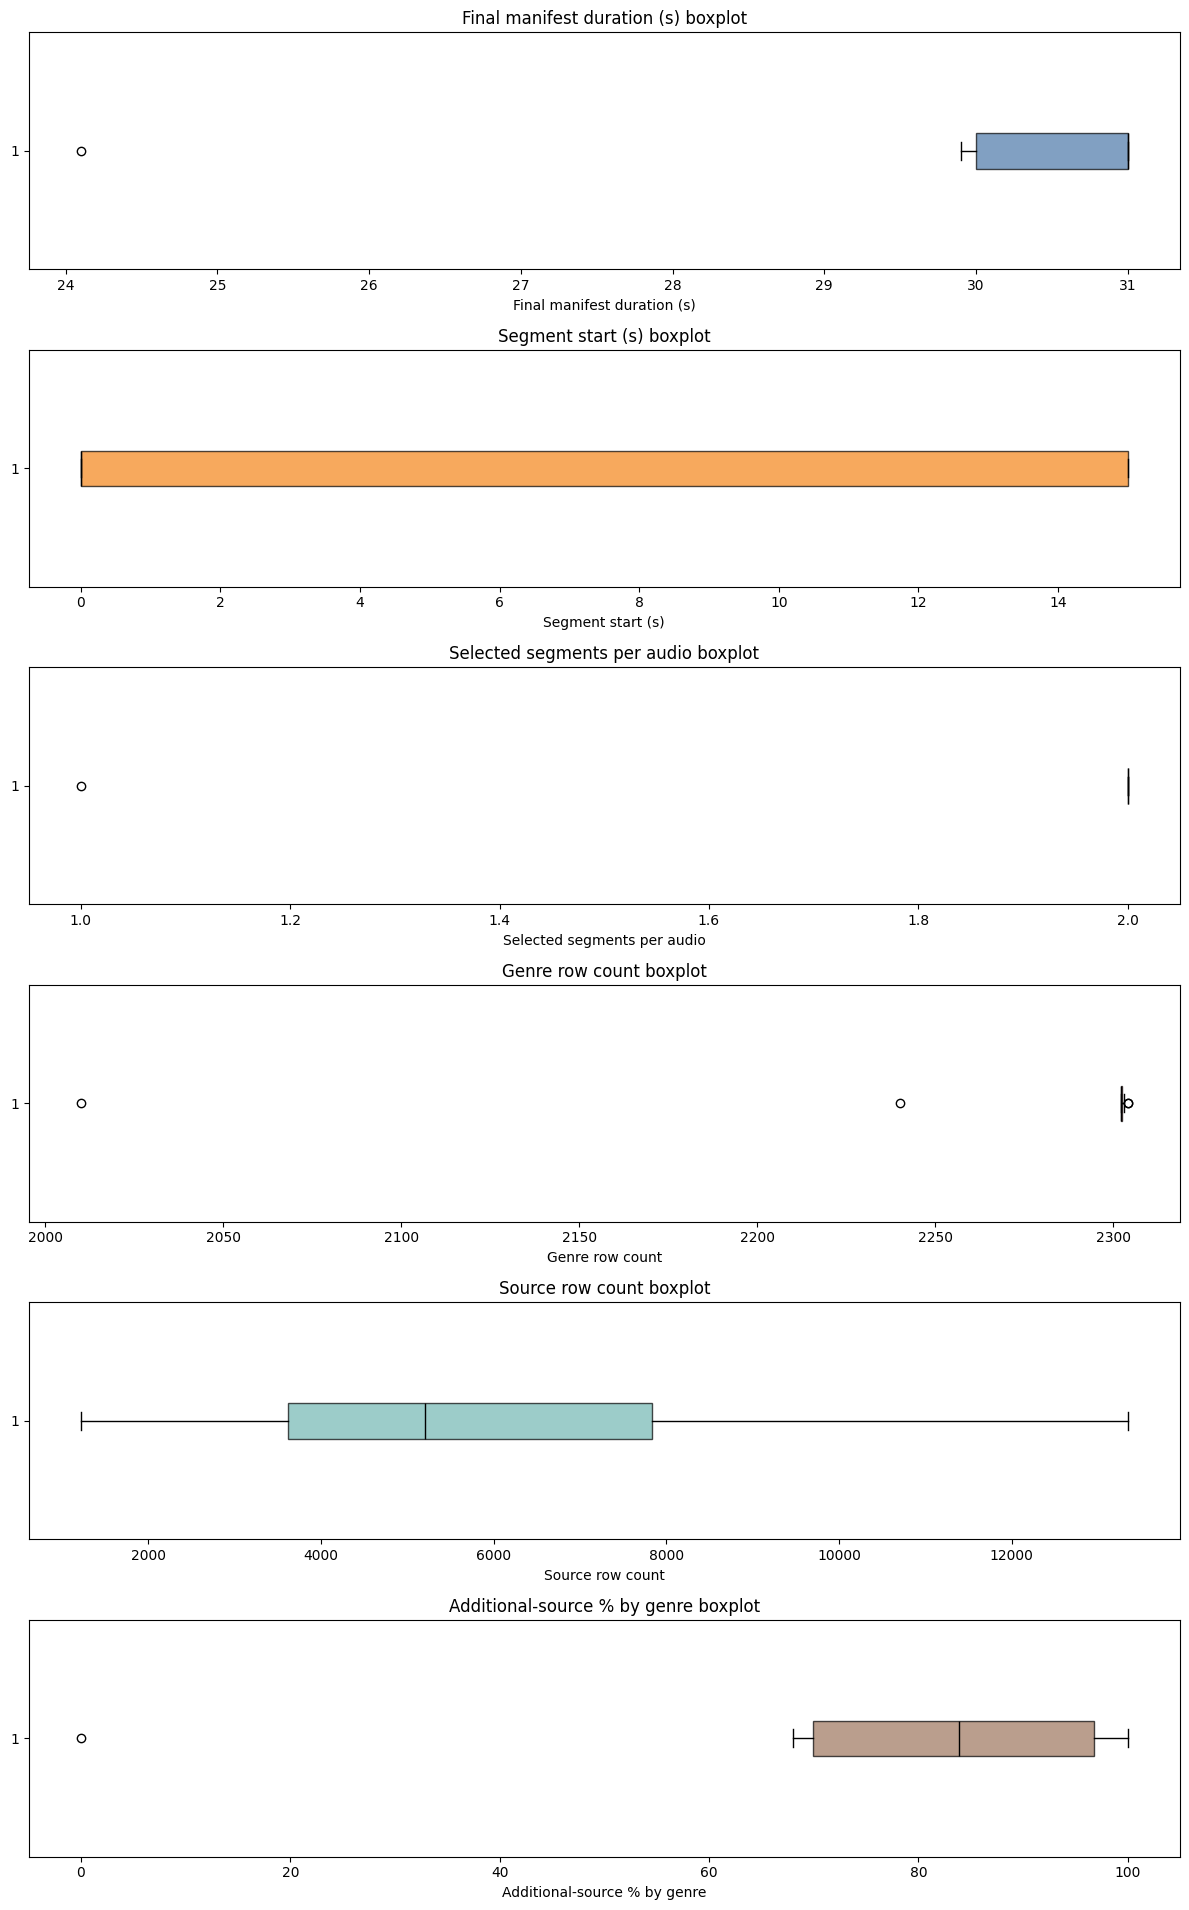

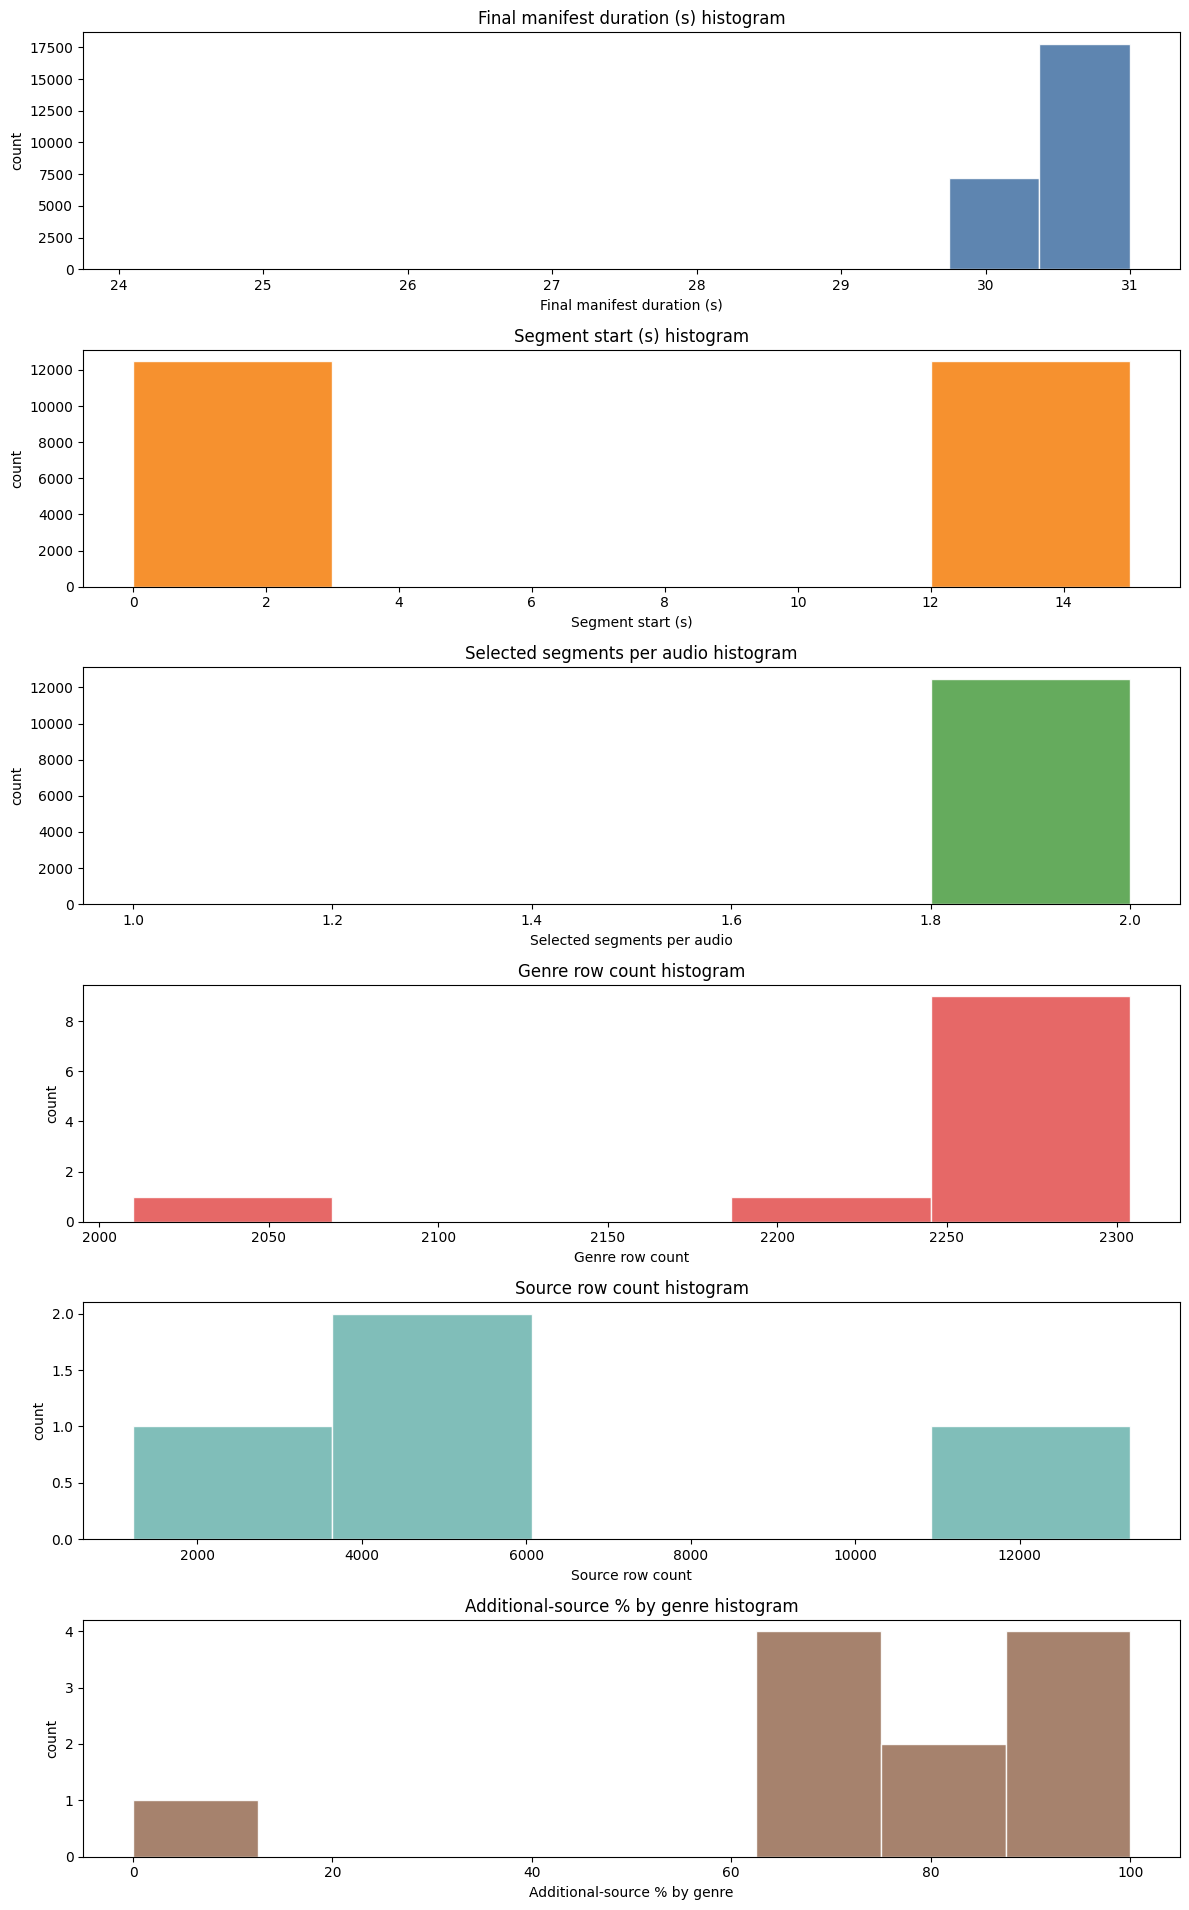

In [ ]:
display(Markdown('## Core Statistical Metrics'))


def prepare_numeric_series(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors='coerce').dropna()
    return numeric[numeric.notna()]


def summarize_numeric_distribution(name: str, series: pd.Series) -> dict[str, object]:
    numeric = prepare_numeric_series(series)
    if numeric.empty:
        return {
            'metric_set': name,
            'count': 0,
            'mean': np.nan,
            'median': np.nan,
            'mode': np.nan,
            'std': np.nan,
            'variance': np.nan,
            'min': np.nan,
            'max': np.nan,
            'skewness': np.nan,
            'kurtosis': np.nan,
        }

    mode_series = numeric.mode(dropna=True)
    return {
        'metric_set': name,
        'count': int(numeric.count()),
        'mean': round(float(numeric.mean()), 2),
        'median': round(float(numeric.median()), 2),
        'mode': round(float(mode_series.iloc[0]), 2) if not mode_series.empty else np.nan,
        'std': round(float(numeric.std(ddof=1)), 2) if len(numeric) > 1 else 0.0,
        'variance': round(float(numeric.var(ddof=1)), 2) if len(numeric) > 1 else 0.0,
        'min': round(float(numeric.min()), 2),
        'max': round(float(numeric.max()), 2),
        'skewness': round(float(numeric.skew()), 2) if len(numeric) > 2 else np.nan,
        'kurtosis': round(float(numeric.kurt()), 2) if len(numeric) > 3 else np.nan,
    }


def plot_distribution_pair(series: pd.Series, title: str, bins: int = 30, color: str = '#4C78A8') -> None:
    numeric = prepare_numeric_series(series)
    if numeric.empty:
        print(f'No data available for {title}')
        return

    _, axes = plt.subplots(1, 2, figsize=(11, 3.5), gridspec_kw={'width_ratios': [4, 1]})
    axes[0].hist(numeric, bins=bins, color=color, alpha=0.9, edgecolor='white')
    axes[0].axvline(numeric.mean(), color='#E45756', linestyle='--', linewidth=1.5, label='mean')
    axes[0].axvline(numeric.median(), color='#54A24B', linestyle='-', linewidth=1.5, label='median')
    axes[0].set_title(f'{title} distribution')
    axes[0].set_xlabel(title)
    axes[0].set_ylabel('count')
    axes[0].legend()

    axes[1].boxplot(numeric, vert=True, patch_artist=True, boxprops={'facecolor': color, 'alpha': 0.7})
    axes[1].set_title('boxplot')
    axes[1].set_xticks([])
    axes[1].set_ylabel(title)

    plt.tight_layout()
    plt.show()


if 'sample_id' in final_target_df.columns:
    file_level_df = final_target_df.copy()
    file_level_df['artifact_id'] = file_level_df['sample_id'].astype(str).str.replace(r':seg\d+$', '', regex=True)
else:
    file_level_df = final_target_df.copy()
    file_level_df['artifact_id'] = file_level_df['filepath'].astype(str) if 'filepath' in file_level_df.columns else np.arange(len(file_level_df)).astype(str)

if 'actual_duration_s' in file_level_df.columns and 'duration_s' in file_level_df.columns:
    file_level_df['file_duration_s'] = pd.to_numeric(file_level_df['actual_duration_s'], errors='coerce').fillna(
        pd.to_numeric(file_level_df['duration_s'], errors='coerce')
    )
elif 'duration_s' in file_level_df.columns:
    file_level_df['file_duration_s'] = pd.to_numeric(file_level_df['duration_s'], errors='coerce')
else:
    file_level_df['file_duration_s'] = np.nan

per_file_summary = file_level_df.groupby('artifact_id').agg(
    source=('source', 'first') if 'source' in file_level_df.columns else ('artifact_id', 'first'),
    genre_top=('genre_top', 'first') if 'genre_top' in file_level_df.columns else ('artifact_id', 'first'),
    filepath=('filepath', 'first') if 'filepath' in file_level_df.columns else ('artifact_id', 'first'),
    file_duration_s=('file_duration_s', 'first'),
    selected_segments=('artifact_id', 'size'),
).reset_index()

file_duration_unique_series = prepare_numeric_series(per_file_summary['file_duration_s'])
segments_per_file_series = prepare_numeric_series(per_file_summary['selected_segments'])
files_per_genre_series = prepare_numeric_series(per_file_summary['genre_top'].value_counts()) if 'genre_top' in per_file_summary.columns else pd.Series(dtype=float)

file_level_kpis = pd.DataFrame([
    {'metric': 'unique_source_files_in_final_target_manifest', 'value': int(per_file_summary['artifact_id'].nunique())},
    {'metric': 'selected_rows_in_final_target_manifest', 'value': int(len(final_target_df))},
    {'metric': 'mean_selected_segments_per_file', 'value': round(float(segments_per_file_series.mean()), 2) if not segments_per_file_series.empty else np.nan},
    {'metric': 'min_selected_segments_per_file', 'value': int(segments_per_file_series.min()) if not segments_per_file_series.empty else np.nan},
    {'metric': 'max_selected_segments_per_file', 'value': int(segments_per_file_series.max()) if not segments_per_file_series.empty else np.nan},
    {'metric': 'mean_source_file_duration_sec', 'value': round(float(file_duration_unique_series.mean()), 2) if not file_duration_unique_series.empty else np.nan},
    {'metric': 'min_source_file_duration_sec', 'value': round(float(file_duration_unique_series.min()), 2) if not file_duration_unique_series.empty else np.nan},
    {'metric': 'max_source_file_duration_sec', 'value': round(float(file_duration_unique_series.max()), 2) if not file_duration_unique_series.empty else np.nan},
])

core_statistical_metrics = pd.DataFrame([
    summarize_numeric_distribution('selected_segments_per_file', segments_per_file_series),
    summarize_numeric_distribution('source_file_duration_sec', file_duration_unique_series),
    summarize_numeric_distribution('unique_files_per_genre', files_per_genre_series),
])

display(Markdown('### File-Level KPI Summary'))
display(file_level_kpis)
display(Markdown('### File-Level Distribution Summary'))
display(core_statistical_metrics)
display(Markdown('Each row in the file-level summary corresponds to one unique source file after deduplicating segment rows using the source artifact id derived from `sample_id`.'))

plot_distribution_pair(segments_per_file_series, title='Selected segments extracted per file', bins=min(30, max(5, int(segments_per_file_series.nunique()))) if not segments_per_file_series.empty else 10, color='#72B7B2')
plot_distribution_pair(file_duration_unique_series, title='Source file duration (sec)', bins=30, color='#4C78A8')

In [ ]:
display(Markdown('## Segment-Level Distribution Summary'))

segment_level_df = final_target_df.copy()

if 'actual_duration_s' in segment_level_df.columns and 'duration_s' in segment_level_df.columns:
    segment_level_df['source_file_duration_s'] = pd.to_numeric(segment_level_df['actual_duration_s'], errors='coerce').fillna(
        pd.to_numeric(segment_level_df['duration_s'], errors='coerce')
    )
elif 'duration_s' in segment_level_df.columns:
    segment_level_df['source_file_duration_s'] = pd.to_numeric(segment_level_df['duration_s'], errors='coerce')
else:
    segment_level_df['source_file_duration_s'] = np.nan

segment_start_series = prepare_numeric_series(segment_level_df['segment_start_sec']) if 'segment_start_sec' in segment_level_df.columns else pd.Series(dtype=float)
segment_end_series = prepare_numeric_series(segment_level_df['segment_end_sec']) if 'segment_end_sec' in segment_level_df.columns else pd.Series(dtype=float)
segment_index_series = prepare_numeric_series(segment_level_df['segment_index']) if 'segment_index' in segment_level_df.columns else pd.Series(dtype=float)
segment_length_series = prepare_numeric_series(
    segment_level_df['sample_length_sec'] if 'sample_length_sec' in segment_level_df.columns else pd.Series(dtype=float)
 )
segment_source_duration_series = prepare_numeric_series(segment_level_df['source_file_duration_s'])
segments_per_genre_series = prepare_numeric_series(segment_level_df['genre_top'].value_counts()) if 'genre_top' in segment_level_df.columns else pd.Series(dtype=float)

segment_level_kpis = pd.DataFrame([
    {'metric': 'selected_segments_in_final_target_manifest', 'value': int(len(segment_level_df))},
    {'metric': 'unique_segment_genres', 'value': int(segment_level_df['genre_top'].nunique()) if 'genre_top' in segment_level_df.columns else np.nan},
    {'metric': 'mean_segment_length_sec', 'value': round(float(segment_length_series.mean()), 2) if not segment_length_series.empty else np.nan},
    {'metric': 'min_segment_length_sec', 'value': round(float(segment_length_series.min()), 2) if not segment_length_series.empty else np.nan},
    {'metric': 'max_segment_length_sec', 'value': round(float(segment_length_series.max()), 2) if not segment_length_series.empty else np.nan},
    {'metric': 'mean_segment_start_sec', 'value': round(float(segment_start_series.mean()), 2) if not segment_start_series.empty else np.nan},
    {'metric': 'min_segment_start_sec', 'value': round(float(segment_start_series.min()), 2) if not segment_start_series.empty else np.nan},
    {'metric': 'max_segment_start_sec', 'value': round(float(segment_start_series.max()), 2) if not segment_start_series.empty else np.nan},
])

segment_distribution_summary = pd.DataFrame([
    summarize_numeric_distribution('segment_length_sec', segment_length_series),
    summarize_numeric_distribution('segment_start_sec', segment_start_series),
    summarize_numeric_distribution('segment_end_sec', segment_end_series),
    summarize_numeric_distribution('segment_index', segment_index_series),
    summarize_numeric_distribution('source_file_duration_attached_to_segments_sec', segment_source_duration_series),
    summarize_numeric_distribution('segments_per_genre', segments_per_genre_series),
])

display(Markdown('### Segment-Level KPI Summary'))
display(segment_level_kpis)
display(Markdown('### Segment-Level Distribution Summary'))
display(segment_distribution_summary)
display(Markdown('Each row in the segment-level summary corresponds to one selected segment row in the final target manifest.'))

plot_distribution_pair(segment_length_series, title='Segment length (sec)', bins=min(20, max(5, int(segment_length_series.nunique()))) if not segment_length_series.empty else 10, color='#54A24B')
plot_distribution_pair(segment_start_series, title='Segment start (sec)', bins=30, color='#F58518')
plot_distribution_pair(segment_end_series, title='Segment end (sec)', bins=30, color='#4C78A8')

## Supplementation-Aware Small-Split Audit

After auditing the generic final manifest, this section narrows to the small-dataset workflow where official FMA membership, live processed split parquets, and staged supplementation payloads can diverge.

That distinction matters because `extra_samples_for_small_dataset.json` may already describe candidate supplementation while the current `train_small`, `val_small`, and `test_small` parquet files may still reflect the unsupplemented state.

This section answers four practical questions when the small workflow is active:

1. What does the official exact FMA-small split look like?
2. What do the current processed `train_small`, `val_small`, and `test_small` parquet files contain right now?
3. Have the live processed small splits already diverged from official exact-small through non-FMA or supplementation-driven rows?
4. What payload is currently staged in `extra_samples_for_small_dataset.json` by genre and source?

If those artifacts are missing, this section skips cleanly and the broader manifest audit still remains valid.

In [31]:
supplementation_audit_ready = False
official_small_df = None
processed_small_df = None
official_small_counts = pd.DataFrame()
processed_small_counts = pd.DataFrame()
processed_small_source_summary = pd.DataFrame()
payload_source_summary = pd.DataFrame()
payload_genre_source_summary = pd.DataFrame()
payload_allocation_summary = pd.DataFrame()
supplementation_metrics_table = pd.DataFrame()
current_has_non_fma_rows = False
selected_payload_rows = 0
official_current_row_delta = 0
new_genres_vs_official_small = []


def stable_row_key(row: dict[str, object]) -> str:
    track_id = row.get('track_id')
    filepath = row.get('filepath') or row.get('relative_path') or row.get('filename') or ''
    return '|'.join([
        str(row.get('source') or ''),
        str(row.get('genre') or row.get('genre_top') or ''),
        '' if track_id is None else str(track_id),
        str(filepath),
    ])


def genre_seed(base_seed: int, genre: str) -> int:
    digest = hashlib.sha1(genre.encode('utf-8')).digest()
    genre_hash = int.from_bytes(digest[:4], byteorder='big', signed=False)
    return base_seed + genre_hash


def deterministic_shuffle(rows: list[dict[str, object]], seed: int, genre: str) -> list[dict[str, object]]:
    shuffled = list(rows)
    shuffled.sort(key=stable_row_key)
    random.Random(genre_seed(seed, genre)).shuffle(shuffled)
    return shuffled


def compute_split_counts(total: int, train_ratio: float) -> dict[str, int]:
    train_count = int(round(total * train_ratio))
    train_count = max(0, min(total, train_count))

    remainder = total - train_count
    if remainder % 2 == 1:
        train_count += 1
        remainder -= 1

    val_count = remainder // 2
    test_count = remainder // 2
    return {
        'training': train_count,
        'validation': val_count,
        'test': test_count,
    }


def counts_by_genre_and_split(frame: pd.DataFrame) -> pd.DataFrame:
    table = pd.crosstab(frame['genre_top'], frame['split'])
    return table.reindex(columns=SUPPLEMENTED_SPLIT_ORDER, fill_value=0).sort_index()


def proportions_from_counts(counts: pd.DataFrame) -> pd.DataFrame:
    return counts.div(counts.sum(axis=0), axis=1).fillna(0.0)


def tvd(p: np.ndarray, q: np.ndarray) -> float:
    return 0.5 * np.abs(p - q).sum()


def jsd(p: np.ndarray, q: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(p, eps, 1.0)
    p = p / p.sum()
    q = np.clip(q, eps, 1.0)
    q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5 * (np.sum(p * np.log2(p / m)) + np.sum(q * np.log2(q / m)))


def split_distance_metrics(counts: pd.DataFrame) -> dict[str, float]:
    props = proportions_from_counts(counts)
    genres = props.index
    p_train = props['training'].reindex(genres).to_numpy()
    p_val = props['validation'].reindex(genres).to_numpy()
    p_test = props['test'].reindex(genres).to_numpy()
    return {
        'TVD(train,val)': tvd(p_train, p_val),
        'TVD(train,test)': tvd(p_train, p_test),
        'JSD(train,val)': jsd(p_train, p_val),
        'JSD(train,test)': jsd(p_train, p_test),
    }


def add_all_column(counts: pd.DataFrame) -> pd.DataFrame:
    table = counts.reindex(columns=SUPPLEMENTED_SPLIT_ORDER, fill_value=0).astype(int).copy()
    table['all'] = table.sum(axis=1)
    return table.sort_values('all', ascending=False)


small_split_paths_exist = all((PROCESSED_DIR / filename).exists() for filename in SUPPLEMENTED_SPLIT_FILES.values())
extra_samples_exists = EXTRA_SAMPLES_PATH.exists()
tracks_csv_exists = TRACKS_CSV.exists()

if tracks_csv_exists and small_split_paths_exist:
    tracks = pd.read_csv(TRACKS_CSV, header=[0, 1], index_col=0)
    official_mask = (
        (tracks[('set', 'subset')] == SUPPLEMENTED_TARGET_SUBSET)
        & tracks[('track', 'genre_top')].notna()
        & tracks[('set', 'split')].isin(SUPPLEMENTED_SPLIT_ORDER)
    )
    official_small_df = tracks.loc[official_mask, [('set', 'split'), ('track', 'genre_top')]].copy()
    official_small_df.columns = ['split', 'genre_top']
    official_small_df['source'] = 'fma'
    official_small_df['sample_id'] = official_small_df.index.map(lambda track_id: f'fma:{int(track_id)}')
    official_small_df.index.name = 'track_id'

    processed_small_frames = []
    for split_name, filename in SUPPLEMENTED_SPLIT_FILES.items():
        split_path = PROCESSED_DIR / filename
        frame = pd.read_parquet(split_path).copy()
        frame['split'] = split_name
        frame.index.name = 'track_id'
        processed_small_frames.append(frame)
    processed_small_df = pd.concat(processed_small_frames, axis=0)

    official_small_counts = counts_by_genre_and_split(official_small_df)
    processed_small_counts = counts_by_genre_and_split(processed_small_df)

    official_split_sizes = official_small_df['split'].value_counts().reindex(SUPPLEMENTED_SPLIT_ORDER, fill_value=0)
    processed_split_sizes = processed_small_df['split'].value_counts().reindex(SUPPLEMENTED_SPLIT_ORDER, fill_value=0)
    split_size_compare = pd.concat(
        [
            official_split_sizes.rename('official_exact_small'),
            processed_split_sizes.rename('processed_current'),
        ],
        axis=1,
    )
    split_size_compare['delta_vs_official'] = split_size_compare['processed_current'] - split_size_compare['official_exact_small']

    processed_small_source_summary = (
        processed_small_df.groupby(['split', 'source']).size().unstack(fill_value=0).reindex(SUPPLEMENTED_SPLIT_ORDER, fill_value=0)
    )

    current_has_non_fma_rows = 'source' in processed_small_df.columns and processed_small_df['source'].astype(str).ne('fma').any()
    new_genres_vs_official_small = sorted(set(processed_small_counts.index) - set(official_small_counts.index))
    official_current_row_delta = int(processed_small_df.shape[0] - official_small_df.shape[0])

    display(Markdown('### Official Exact-Small vs Current Processed Small Splits'))
    display(split_size_compare)
    display(Markdown('### Current Processed Small Source Mix by Split'))
    display(processed_small_source_summary)
    print(f'Non-FMA rows already present in processed small splits? {current_has_non_fma_rows}')
    print(f'Genres outside official exact-small currently present: {new_genres_vs_official_small}')

    display(Markdown('### Official Exact-Small Genre Counts'))
    display(official_small_counts)
    display(Markdown('### Current Processed Small Genre Counts'))
    display(processed_small_counts)

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))
    pd.DataFrame({
        'official': official_split_sizes,
        'current': processed_split_sizes,
    }).plot(kind='bar', ax=axes[0], width=0.75)
    axes[0].set_title('Split sizes: official vs current small')
    axes[0].set_ylabel('Rows')
    axes[0].tick_params(axis='x', rotation=0)

    top_genres = (
        processed_small_counts.sum(axis=1)
        .add(official_small_counts.sum(axis=1), fill_value=0)
        .sort_values(ascending=False)
        .head(12)
        .index
    )
    training_compare = pd.DataFrame({
        'official_training': official_small_counts['training'].reindex(top_genres, fill_value=0),
        'current_training': processed_small_counts['training'].reindex(top_genres, fill_value=0),
    })
    training_compare.plot(kind='bar', ax=axes[1], width=0.8)
    axes[1].set_title('Training split genre counts (top 12)')
    axes[1].set_ylabel('Rows')
    axes[1].tick_params(axis='x', rotation=55)

    if not processed_small_source_summary.empty:
        processed_small_source_summary.plot(kind='bar', stacked=True, ax=axes[2], width=0.75)
        axes[2].set_title('Current processed small source mix by split')
        axes[2].set_ylabel('Rows')
        axes[2].tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

    supplementation_metrics_table = pd.DataFrame({
        'official_exact_small': split_distance_metrics(official_small_counts),
        'processed_current': split_distance_metrics(processed_small_counts),
    }).T.round(4)
    display(Markdown('### Split-Distance Metrics'))
    display(supplementation_metrics_table)

if extra_samples_exists and settings_payload is not None:
    extra_samples_payload = json.loads(EXTRA_SAMPLES_PATH.read_text())
    supplementation_settings = settings_payload.get('small_dataset_supplementation', {})
    target_genres = supplementation_settings.get('target_genres', [])
    n_extra_expected = int(supplementation_settings.get('n_extra_expected', 0) or 0)
    train_ratio = float(supplementation_settings.get('train_n_val_test_split_ratio', 0.8) or 0.8)
    selected_tracks = extra_samples_payload.get('selected_tracks', {})

    allocation_records = []
    allocation_summary_records = []
    for genre in target_genres:
        genre_rows = list(selected_tracks.get(genre, []))[:n_extra_expected]
        shuffled_rows = deterministic_shuffle(genre_rows, SUPPLEMENTATION_BASE_RANDOM_SEED, genre)
        split_counts = compute_split_counts(len(shuffled_rows), train_ratio)

        for row in shuffled_rows:
            allocation_records.append({
                'genre_top': genre,
                'source': row.get('source', 'unknown'),
                'track_id': row.get('track_id'),
                'filepath': row.get('filepath'),
            })

        allocation_summary_records.append({
            'genre_top': genre,
            'selected_rows_used': len(shuffled_rows),
            'cap_per_genre': n_extra_expected,
            'train_would_get': split_counts['training'],
            'validation_would_get': split_counts['validation'],
            'test_would_get': split_counts['test'],
        })

    allocation_df = pd.DataFrame(allocation_records)
    payload_allocation_summary = pd.DataFrame(allocation_summary_records).set_index('genre_top').sort_values('selected_rows_used', ascending=False)
    selected_payload_rows = int(len(allocation_df))

    display(Markdown('### Supplementation Payload Allocation Summary'))
    display(payload_allocation_summary)

    if allocation_df.empty:
        print('No selected supplementation rows were found in extra_samples_for_small_dataset.json.')
    else:
        payload_source_summary = (
            allocation_df.groupby('source').size().rename('selected_rows').sort_values(ascending=False).to_frame()
        )
        payload_genre_source_summary = (
            allocation_df.groupby(['genre_top', 'source']).size().unstack(fill_value=0).sort_index()
        )
        display(Markdown('### Supplementation Payload Source Mix'))
        display(payload_source_summary)
        display(Markdown('### Supplementation Payload Rows by Genre and Source'))
        display(payload_genre_source_summary)

        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        payload_allocation_summary['selected_rows_used'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='#4C78A8')
        axes[0].set_title('Selected supplementation payload rows per target genre')
        axes[0].set_ylabel('Rows')
        axes[0].tick_params(axis='x', rotation=55)

        payload_source_summary['selected_rows'].plot(kind='bar', ax=axes[1], color='#F58518')
        axes[1].set_title('Supplementation payload source mix')
        axes[1].set_ylabel('Rows')
        axes[1].tick_params(axis='x', rotation=35)
        plt.tight_layout()
        plt.show()

supplementation_audit_ready = tracks_csv_exists and small_split_paths_exist
if not supplementation_audit_ready:
    print('Supplementation-aware small-split audit is skipped because official small metadata or processed small split parquet files are missing.')
if not extra_samples_exists:
    print('No extra_samples_for_small_dataset.json found; payload provenance portion of the supplementation-aware audit is unavailable.')

Supplementation-aware small-split audit is skipped because official small metadata or processed small split parquet files are missing.
No extra_samples_for_small_dataset.json found; payload provenance portion of the supplementation-aware audit is unavailable.


## Downstream Log-Mel and TFRecord Audit

This section checks the handoff from the selected final manifest into the downstream preprocessing commands the current staged pipeline actually runs:

1. log-mel materialization by `2_build_log_mel_dataset.py`
2. TFRecord conversion by `3_convert_npy_2_tfrecord.py`
3. optional latest saved training-run metadata only when a run report exists

The notebook remains valid after the preprocessing sequence ending at `3_convert_npy_2_tfrecord.py`; training-run metadata is treated as a historical sidecar audit rather than a required dependency.

Because `2_build_log_mel_dataset.py` filters rows by `settings.data_sampling_settings.target_genres`, this section separates:

- final-manifest rows that are eligible for downstream feature generation
- rows intentionally excluded by configured target-genre filtering
- rows that reached log-mel but were skipped during feature extraction
- rows that should have reached TFRecord conversion but did not
- any mismatch between the current live preprocessing dataset and the latest saved training run report

### Downstream Artifact Inventory

,artifact,exists
0,logmel_build_report.txt,True
1,logmel_config.json,True
2,logmel_manifest_all.parquet,True
3,logmel_manifest_train.parquet,True
4,logmel_manifest_val.parquet,True
5,logmel_manifest_test.parquet,True
6,tfrecord_build_report.txt,True
7,tfrecord_config.json,True
8,tfrecord_manifest_all.parquet,True
9,tfrecord_manifest_train.parquet,True


### Live Downstream Configuration Snapshot

,config,key,value
0,logmel_config.json,available,True
1,logmel_config.json,sample_length_sec,15.0
2,logmel_config.json,rows_requested,22671
3,logmel_config.json,target_genres,"[""Hip-Hop"", ""Pop"", ""Rock"", ""Metal"", ""Classical"", ""Jazz"", ""Country"", ""Blues"", ""Bolero"", ""Speech""]"
4,logmel_config.json,logmel_dataset_dir,None
5,tfrecord_config.json,available,True
6,tfrecord_config.json,sample_length_sec,15.0
7,tfrecord_config.json,genre_classes,"[""Blues"", ""Bolero"", ""Classical"", ""Country"", ""Hip-Hop"", ""Jazz"", ""Metal"", ""Pop"", ""Rock"", ""Speech""]"
8,tfrecord_config.json,split_counts,None
9,tfrecord_config.json,tfrecord_dataset_dir,None


### Configured Target Genres

...

,genre_top,excluded_rows
0,Electronic,2302


### Compact Artifact Inventory

,artifact,metric,value
0,logmel_manifest_all,present,True
1,logmel_manifest_all,rows,22671
2,logmel_manifest_all,columns,25
3,logmel_manifest_all,genre_count,10
4,logmel_manifest_all,split_count,3
5,logmel_manifest_all,status_count,2
6,tfrecord_manifest_all,present,True
7,tfrecord_manifest_all,rows,22037
8,tfrecord_manifest_all,columns,32
9,tfrecord_manifest_all,genre_count,10


### Log-Mel Summary

,metric,value
0,logmel_manifest_all_rows,22671
1,logmel_manifest_train_rows,15406
2,logmel_manifest_val_rows,3309
3,logmel_manifest_test_rows,3322
4,usable_logmels_all,22037
5,missing_logmels_all,634
6,live_logmel_genre_count,10


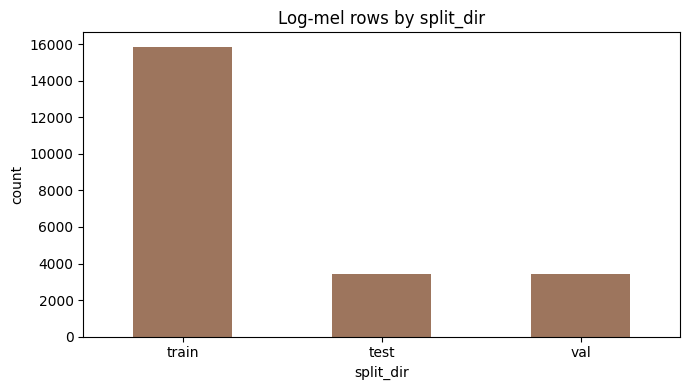

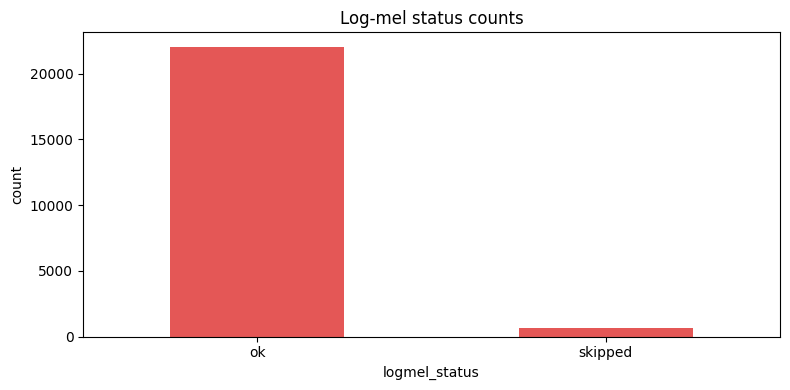

### Final Manifest to Log-Mel Alignment

,metric,value
0,final_manifest_rows,24973
1,target_genre_eligible_rows,22671
2,filtered_out_by_target_genres,2302
3,matched_logmel_rows,22671
4,missing_logmel_rows_from_eligible,0
5,matched_and_usable,22037
6,matched_but_skipped,634


### TFRecord Summary

,metric,value
0,tfrecord_manifest_all_rows,22037
1,tfrecord_manifest_train_rows,15406
2,tfrecord_manifest_val_rows,3309
3,tfrecord_manifest_test_rows,3322
4,label_int_unique,10
5,live_tfrecord_genre_count,10


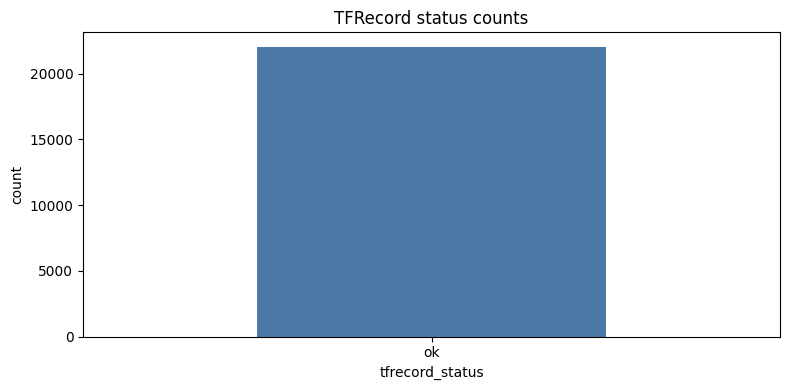

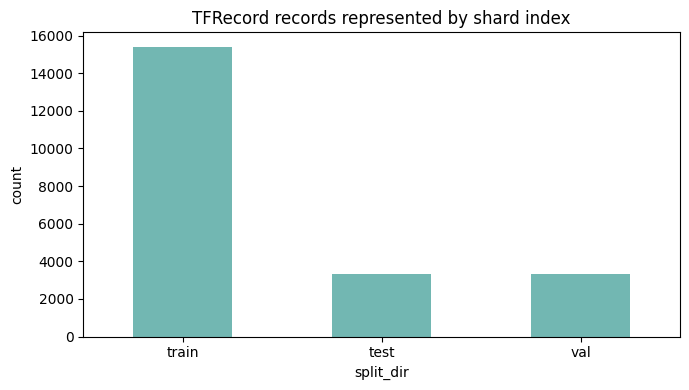

### Final Manifest to TFRecord Alignment

,metric,value
0,final_manifest_rows,24973
1,target_genre_eligible_rows,22671
2,filtered_out_by_target_genres,2302
3,usable_logmel_rows_expected_for_tfrecord,22037
4,matched_tfrecord_rows,22037
5,missing_tfrecord_rows_from_usable_logmels,0


### Current Live Preprocessed Dataset Summary

,metric,value
0,configured_target_genre_count,10
1,configured_target_genres,"Hip-Hop, Pop, Rock, Metal, Classical, Jazz, Country, Blues, Bolero, Speech"
2,live_final_target_eligible_genre_count,10
3,live_final_target_eligible_rows,22671
4,live_logmel_genre_count,10
5,live_logmel_genres,"Blues, Bolero, Classical, Country, Hip-Hop, Jazz, Metal, Pop, Rock, Speech"
6,live_tfrecord_genre_count,10
7,live_tfrecord_genres,"Blues, Bolero, Classical, Country, Hip-Hop, Jazz, Metal, Pop, Rock, Speech"


### Historical Saved Training Run Snapshot

This archived run report is not the current live preprocessing dataset. It is shown only for drift comparison against the live 10-genre artifacts above.

,metric,value
0,latest_run_id,logmel-cnn-20260321-070615
1,latest_run_subset,small
2,latest_run_reported_n_classes,8
3,latest_run_reported_genre_count,8
4,latest_run_reported_genres,"Electronic, Experimental, Folk, Hip-Hop, Instrumental, International, Pop, Rock"
5,current_configured_target_genre_count,10
6,current_live_tfrecord_genre_count,10
7,run_report_matches_current_live_genres,False
8,genres_only_in_latest_run_report,"Electronic, Experimental, Folk, Instrumental, International"
9,genres_only_in_current_live_dataset,"Blues, Bolero, Classical, Country, Jazz, Metal, Speech"


In [32]:
configured_target_genres = []
for genre in sampling_settings.get('target_genres', []):
    if isinstance(genre, str) and genre.strip() and genre.strip() not in configured_target_genres:
        configured_target_genres.append(genre.strip())
for genre in (logmel_config or {}).get('target_genres', []):
    if isinstance(genre, str) and genre.strip() and genre.strip() not in configured_target_genres:
        configured_target_genres.append(genre.strip())
for genre in (tfrecord_config or {}).get('target_genres', []):
    if isinstance(genre, str) and genre.strip() and genre.strip() not in configured_target_genres:
        configured_target_genres.append(genre.strip())

def compact_manifest_summary(name: str, df: pd.DataFrame | None, split_col: str | None = None, status_col: str | None = None) -> pd.DataFrame:
    if df is None:
        return pd.DataFrame([
            {'artifact': name, 'metric': 'present', 'value': False},
        ])

    summary_rows = [
        {'artifact': name, 'metric': 'present', 'value': True},
        {'artifact': name, 'metric': 'rows', 'value': len(df)},
        {'artifact': name, 'metric': 'columns', 'value': len(df.columns)},
    ]

    if 'genre_top' in df.columns:
        summary_rows.append({'artifact': name, 'metric': 'genre_count', 'value': int(df['genre_top'].nunique())})
    if split_col and split_col in df.columns:
        summary_rows.append({'artifact': name, 'metric': 'split_count', 'value': int(df[split_col].nunique())})
    if status_col and status_col in df.columns:
        summary_rows.append({'artifact': name, 'metric': 'status_count', 'value': int(df[status_col].nunique())})

    return pd.DataFrame(summary_rows)

def selected_config_rows(name: str, payload: dict[str, object] | None, keys: list[str]) -> pd.DataFrame:
    if not payload:
        return pd.DataFrame([{'config': name, 'key': 'available', 'value': False}])

    rows = [{'config': name, 'key': 'available', 'value': True}]
    for key in keys:
        value = payload.get(key)
        if isinstance(value, (dict, list)):
            value = json.dumps(value, ensure_ascii=False)
        rows.append({'config': name, 'key': key, 'value': value})
    return pd.DataFrame(rows)

target_genre_mask = (
    final_samples_df['genre_top'].isin(configured_target_genres)
    if configured_target_genres
    else pd.Series(True, index=final_samples_df.index)
)
final_target_eligible_df = final_samples_df[target_genre_mask].copy()
final_target_excluded_df = final_samples_df[~target_genre_mask].copy()

artifact_inventory = pd.DataFrame([
    {'artifact': 'logmel_build_report.txt', 'exists': LOGMEL_BUILD_REPORT_PATH is not None and LOGMEL_BUILD_REPORT_PATH.exists()},
    {'artifact': 'logmel_config.json', 'exists': LOGMEL_CONFIG_PATH is not None and LOGMEL_CONFIG_PATH.exists()},
    {'artifact': 'logmel_manifest_all.parquet', 'exists': LOGMEL_ALL_PATH is not None and LOGMEL_ALL_PATH.exists()},
    {'artifact': 'logmel_manifest_train.parquet', 'exists': LOGMEL_TRAIN_PATH is not None and LOGMEL_TRAIN_PATH.exists()},
    {'artifact': 'logmel_manifest_val.parquet', 'exists': LOGMEL_VAL_PATH is not None and LOGMEL_VAL_PATH.exists()},
    {'artifact': 'logmel_manifest_test.parquet', 'exists': LOGMEL_TEST_PATH is not None and LOGMEL_TEST_PATH.exists()},
    {'artifact': 'tfrecord_build_report.txt', 'exists': TFRECORD_BUILD_REPORT_PATH is not None and TFRECORD_BUILD_REPORT_PATH.exists()},
    {'artifact': 'tfrecord_config.json', 'exists': TFRECORD_CONFIG_PATH is not None and TFRECORD_CONFIG_PATH.exists()},
    {'artifact': 'tfrecord_manifest_all.parquet', 'exists': TFRECORD_ALL_PATH is not None and TFRECORD_ALL_PATH.exists()},
    {'artifact': 'tfrecord_manifest_train.parquet', 'exists': TFRECORD_TRAIN_PATH is not None and TFRECORD_TRAIN_PATH.exists()},
    {'artifact': 'tfrecord_manifest_val.parquet', 'exists': TFRECORD_VAL_PATH is not None and TFRECORD_VAL_PATH.exists()},
    {'artifact': 'tfrecord_manifest_test.parquet', 'exists': TFRECORD_TEST_PATH is not None and TFRECORD_TEST_PATH.exists()},
    {'artifact': 'tfrecord_shards_all.parquet', 'exists': TFRECORD_SHARDS_ALL_PATH is not None and TFRECORD_SHARDS_ALL_PATH.exists()},
    {'artifact': 'latest_run_report', 'exists': LATEST_RUN_REPORT_PATH is not None and LATEST_RUN_REPORT_PATH.exists()},
])
display(Markdown('### Downstream Artifact Inventory'))
display(artifact_inventory)

config_rows = pd.concat(
    [
        selected_config_rows(
            'logmel_config.json',
            logmel_config,
            ['sample_length_sec', 'rows_requested', 'target_genres', 'logmel_dataset_dir'],
        ),
        selected_config_rows(
            'tfrecord_config.json',
            tfrecord_config,
            ['sample_length_sec', 'genre_classes', 'split_counts', 'tfrecord_dataset_dir'],
        ),
    ],
    ignore_index=True,
)
display(Markdown('### Live Downstream Configuration Snapshot'))
display(config_rows)

configured_target_genres_table = pd.DataFrame({'configured_target_genres': configured_target_genres})
display(Markdown('### Configured Target Genres'))
if configured_target_genres_table.empty:
    print('No configured target genres were found; downstream eligibility defaults to the full final manifest.')
else:
    display(configured_target_genres_table)

target_handoff_summary = pd.DataFrame([
    {'metric': 'final_manifest_rows', 'value': len(final_samples_df)},
    {'metric': 'target_genre_eligible_rows', 'value': len(final_target_eligible_df)},
    {'metric': 'filtered_out_by_target_genres', 'value': len(final_target_excluded_df)},
    {'metric': 'configured_target_genre_count', 'value': len(configured_target_genres)},
])
display(Markdown('### Final Manifest Target-Genre Handoff'))
display(target_handoff_summary)

if not final_target_excluded_df.empty:
    excluded_genre_counts = final_target_excluded_df['genre_top'].value_counts().rename_axis('genre_top').reset_index(name='excluded_rows')
    display(Markdown('### Final Manifest Rows Excluded by Target Genres'))
    display(excluded_genre_counts)

final_key_cols = ['sample_id', 'genre_top', 'segment_index', 'segment_start_sec', 'sample_length_sec']
logmel_key_cols = ['sample_id', 'genre_top', 'segment_index', 'segment_start_sec', 'sample_length_sec']
tfrecord_key_cols = ['sample_id', 'genre_top', 'segment_index', 'segment_start_sec', 'sample_length_sec']

logmel_alignment = pd.DataFrame()
expected_tfrecord_input_df = pd.DataFrame(columns=final_key_cols + ['final_split'])
tfrecord_alignment = pd.DataFrame()
logmel_missing_rows_from_eligible = 0
logmel_skipped_rows = 0
tfrecord_missing_rows_from_usable_logmels = 0

live_logmel_genres = []
live_tfrecord_genres = []
current_live_dataset_summary = pd.DataFrame()
historical_run_alignment_summary = pd.DataFrame()

manifest_inventory_summary = pd.concat(
    [
        compact_manifest_summary('logmel_manifest_all', logmel_all_df, split_col='split_dir', status_col='logmel_status'),
        compact_manifest_summary('tfrecord_manifest_all', tfrecord_all_df, split_col='split_dir', status_col='tfrecord_status'),
        compact_manifest_summary('tfrecord_shards_all', tfrecord_shards_all_df, split_col='split_dir'),
    ],
    ignore_index=True,
)
display(Markdown('### Compact Artifact Inventory'))
display(manifest_inventory_summary)

if logmel_all_df is None:
    print('No logmel_manifest_all.parquet found under the detected log-mel root.')
else:
    logmel_summary = pd.DataFrame([
        {'metric': 'logmel_manifest_all_rows', 'value': len(logmel_all_df)},
        {'metric': 'logmel_manifest_train_rows', 'value': 0 if logmel_train_df is None else len(logmel_train_df)},
        {'metric': 'logmel_manifest_val_rows', 'value': 0 if logmel_val_df is None else len(logmel_val_df)},
        {'metric': 'logmel_manifest_test_rows', 'value': 0 if logmel_test_df is None else len(logmel_test_df)},
        {'metric': 'usable_logmels_all', 'value': int(logmel_all_df['logmel_usable'].sum()) if 'logmel_usable' in logmel_all_df.columns else None},
        {'metric': 'missing_logmels_all', 'value': int((~logmel_all_df['logmel_usable'].fillna(False)).sum()) if 'logmel_usable' in logmel_all_df.columns else None},
        {'metric': 'live_logmel_genre_count', 'value': int(logmel_all_df['genre_top'].nunique()) if 'genre_top' in logmel_all_df.columns else None},
    ])
    display(Markdown('### Log-Mel Summary'))
    display(logmel_summary)

    split_dir_counts = logmel_all_df['split_dir'].value_counts().sort_index()
    plot_bar(split_dir_counts, title='Log-mel rows by split_dir', xlabel='split_dir', rotation=0, figsize=(7, 4), color='#9D755D')

    if 'logmel_status' in logmel_all_df.columns:
        status_counts = logmel_all_df['logmel_status'].value_counts()
        plot_bar(status_counts, title='Log-mel status counts', xlabel='logmel_status', rotation=0, figsize=(8, 4), color='#E45756')

    live_logmel_genres = sorted(logmel_all_df['genre_top'].dropna().astype(str).unique().tolist()) if 'genre_top' in logmel_all_df.columns else []

    logmel_alignment = final_target_eligible_df[final_key_cols + ['final_split']].merge(
        logmel_all_df[logmel_key_cols + ['split_dir', 'logmel_path', 'logmel_status', 'logmel_usable']],
        on=logmel_key_cols,
        how='left',
        indicator=True,
    )
    logmel_missing_rows_from_eligible = int((logmel_alignment['_merge'] != 'both').sum())
    logmel_skipped_rows = int(
        ((logmel_alignment['_merge'] == 'both') & (~logmel_alignment['logmel_usable'].fillna(False))).sum()
    )
    logmel_alignment_summary = pd.DataFrame([
        {'metric': 'final_manifest_rows', 'value': len(final_samples_df)},
        {'metric': 'target_genre_eligible_rows', 'value': len(final_target_eligible_df)},
        {'metric': 'filtered_out_by_target_genres', 'value': len(final_target_excluded_df)},
        {'metric': 'matched_logmel_rows', 'value': int((logmel_alignment['_merge'] == 'both').sum())},
        {'metric': 'missing_logmel_rows_from_eligible', 'value': logmel_missing_rows_from_eligible},
        {'metric': 'matched_and_usable', 'value': int(((logmel_alignment['_merge'] == 'both') & (logmel_alignment['logmel_usable'] == True)).sum())},
        {'metric': 'matched_but_skipped', 'value': logmel_skipped_rows},
    ])
    display(Markdown('### Final Manifest to Log-Mel Alignment'))
    display(logmel_alignment_summary)
    if logmel_missing_rows_from_eligible > 0:
        display(logmel_alignment[logmel_alignment['_merge'] != 'both'].head(20))

    expected_tfrecord_input_df = logmel_alignment[
        (logmel_alignment['_merge'] == 'both') & (logmel_alignment['logmel_usable'] == True)
    ][final_key_cols + ['final_split']].copy()

if tfrecord_all_df is None:
    print('No tfrecord_manifest_all.parquet found under the detected TFRecord root.')
else:
    tfrecord_summary = pd.DataFrame([
        {'metric': 'tfrecord_manifest_all_rows', 'value': len(tfrecord_all_df)},
        {'metric': 'tfrecord_manifest_train_rows', 'value': 0 if tfrecord_train_df is None else len(tfrecord_train_df)},
        {'metric': 'tfrecord_manifest_val_rows', 'value': 0 if tfrecord_val_df is None else len(tfrecord_val_df)},
        {'metric': 'tfrecord_manifest_test_rows', 'value': 0 if tfrecord_test_df is None else len(tfrecord_test_df)},
        {'metric': 'label_int_unique', 'value': int(tfrecord_all_df['label_int'].nunique()) if 'label_int' in tfrecord_all_df.columns else None},
        {'metric': 'live_tfrecord_genre_count', 'value': int(tfrecord_all_df['genre_top'].nunique()) if 'genre_top' in tfrecord_all_df.columns else None},
    ])
    display(Markdown('### TFRecord Summary'))
    display(tfrecord_summary)

    if 'tfrecord_status' in tfrecord_all_df.columns:
        tfrecord_status_counts = tfrecord_all_df['tfrecord_status'].value_counts()
        plot_bar(tfrecord_status_counts, title='TFRecord status counts', xlabel='tfrecord_status', rotation=0, figsize=(8, 4), color='#4C78A8')

    if tfrecord_shards_all_df is not None:
        shard_counts_by_split = tfrecord_shards_all_df.groupby('split_dir')['records_in_shard'].sum().sort_index()
        plot_bar(shard_counts_by_split, title='TFRecord records represented by shard index', xlabel='split_dir', rotation=0, figsize=(7, 4), color='#72B7B2')

    live_tfrecord_genres = sorted(tfrecord_all_df['genre_top'].dropna().astype(str).unique().tolist()) if 'genre_top' in tfrecord_all_df.columns else []

    tfrecord_alignment = expected_tfrecord_input_df[tfrecord_key_cols + ['final_split']].merge(
        tfrecord_all_df[tfrecord_key_cols + ['split_dir', 'tfrecord_path', 'tfrecord_status']],
        on=tfrecord_key_cols,
        how='left',
        indicator=True,
    )
    tfrecord_missing_rows_from_usable_logmels = int((tfrecord_alignment['_merge'] != 'both').sum())
    tfrecord_alignment_summary = pd.DataFrame([
        {'metric': 'final_manifest_rows', 'value': len(final_samples_df)},
        {'metric': 'target_genre_eligible_rows', 'value': len(final_target_eligible_df)},
        {'metric': 'filtered_out_by_target_genres', 'value': len(final_target_excluded_df)},
        {'metric': 'usable_logmel_rows_expected_for_tfrecord', 'value': len(expected_tfrecord_input_df)},
        {'metric': 'matched_tfrecord_rows', 'value': int((tfrecord_alignment['_merge'] == 'both').sum())},
        {'metric': 'missing_tfrecord_rows_from_usable_logmels', 'value': tfrecord_missing_rows_from_usable_logmels},
    ])
    display(Markdown('### Final Manifest to TFRecord Alignment'))
    display(tfrecord_alignment_summary)
    if tfrecord_missing_rows_from_usable_logmels > 0:
        display(tfrecord_alignment[tfrecord_alignment['_merge'] != 'both'].head(20))

current_live_dataset_summary = pd.DataFrame([
    {'metric': 'configured_target_genre_count', 'value': len(configured_target_genres)},
    {'metric': 'configured_target_genres', 'value': ', '.join(configured_target_genres)},
    {'metric': 'live_final_target_eligible_genre_count', 'value': final_target_eligible_df['genre_top'].nunique()},
    {'metric': 'live_final_target_eligible_rows', 'value': len(final_target_eligible_df)},
    {'metric': 'live_logmel_genre_count', 'value': len(live_logmel_genres)},
    {'metric': 'live_logmel_genres', 'value': ', '.join(live_logmel_genres)},
    {'metric': 'live_tfrecord_genre_count', 'value': len(live_tfrecord_genres)},
    {'metric': 'live_tfrecord_genres', 'value': ', '.join(live_tfrecord_genres)},
])
display(Markdown('### Current Live Preprocessed Dataset Summary'))
display(current_live_dataset_summary)

if isinstance(run_report, dict):
    historical_run_genres = []
    for genre in run_report.get('dataset', {}).get('genres', []):
        if isinstance(genre, str) and genre.strip():
            historical_run_genres.append(genre.strip())

    display(Markdown('### Historical Saved Training Run Snapshot'))
    display(Markdown('This archived run report is not the current live preprocessing dataset. It is shown only for drift comparison against the live 10-genre artifacts above.'))

    historical_run_alignment_summary = pd.DataFrame([
        {'metric': 'latest_run_id', 'value': run_report.get('run_id')},
        {'metric': 'latest_run_subset', 'value': run_report.get('subset')},
        {'metric': 'latest_run_reported_n_classes', 'value': run_report.get('dataset', {}).get('n_classes')},
        {'metric': 'latest_run_reported_genre_count', 'value': len(historical_run_genres)},
        {'metric': 'latest_run_reported_genres', 'value': ', '.join(historical_run_genres)},
        {'metric': 'current_configured_target_genre_count', 'value': len(configured_target_genres)},
        {'metric': 'current_live_tfrecord_genre_count', 'value': len(live_tfrecord_genres)},
        {'metric': 'run_report_matches_current_live_genres', 'value': historical_run_genres == live_tfrecord_genres},
        {'metric': 'genres_only_in_latest_run_report', 'value': ', '.join(sorted(set(historical_run_genres) - set(live_tfrecord_genres)))},
        {'metric': 'genres_only_in_current_live_dataset', 'value': ', '.join(sorted(set(live_tfrecord_genres) - set(historical_run_genres)))},
    ])
    display(historical_run_alignment_summary)
else:
    print('No downstream training run report was found. That is expected when only the preprocessing commands were run.')

## Final Training Dataset Summary

This section summarizes the live downstream training dataset that would actually be consumed by model training.

It focuses on:

- class count and class list
- label-to-genre mapping when available
- train/validation/test split sizes
- per-genre sample counts
- per-genre counts by split

### Final Training Dataset Overview

,metric,value
0,dataset_source,tfrecord_manifest_all
1,total_rows,22037
2,n_classes,10
3,genre_list,"Blues, Bolero, Classical, Country, Hip-Hop, Jazz, Metal, Pop, Rock, Speech"
4,sample_length_sec,15.0
5,split_column,split_dir


### Final Training Dataset Classes

,label_int,genre_top
0,0,Blues
1,1,Bolero
2,2,Classical
3,3,Country
4,4,Hip-Hop
5,5,Jazz
6,6,Metal
7,7,Pop
8,8,Rock
9,9,Speech


### Final Training Dataset Split Sizes

...

### Final Training Dataset Samples by Genre

,genre_top,rows,share_pct
0,Blues,2262,10.26
1,Jazz,2248,10.20
2,Bolero,2240,10.16
3,Rock,2240,10.16
4,Hip-Hop,2238,10.16
5,Classical,2235,10.14
6,Pop,2228,10.11
7,Speech,2225,10.10
8,Country,2175,9.87
9,Metal,1946,8.83


### Final Training Dataset Samples by Genre and Split

split_dir,train,val,test
genre_top,,,
Blues,1582,339,341
Bolero,1573,334,333
Classical,1558,337,340
Country,1520,329,326
Hip-Hop,1564,335,339
Jazz,1572,337,339
Metal,1363,288,295
Pop,1558,334,336
Rock,1573,333,334


split_dir,train,val,test
genre_top,,,
Blues,69.94,14.99,15.08
Bolero,70.22,14.91,14.87
Classical,69.71,15.08,15.21
Country,69.89,15.13,14.99
Hip-Hop,69.88,14.97,15.15
Jazz,69.93,14.99,15.08
Metal,70.04,14.80,15.16
Pop,69.93,14.99,15.08
Rock,70.22,14.87,14.91


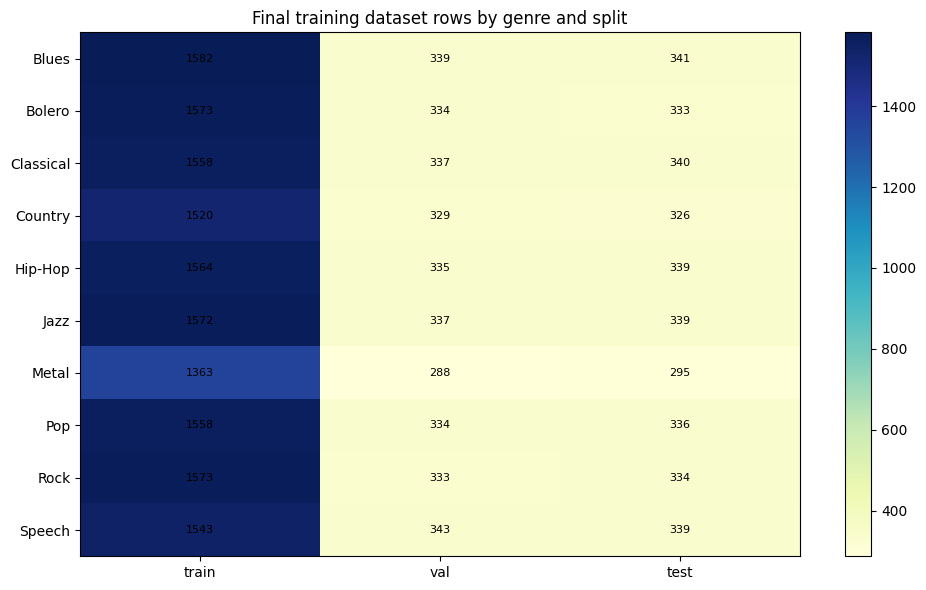

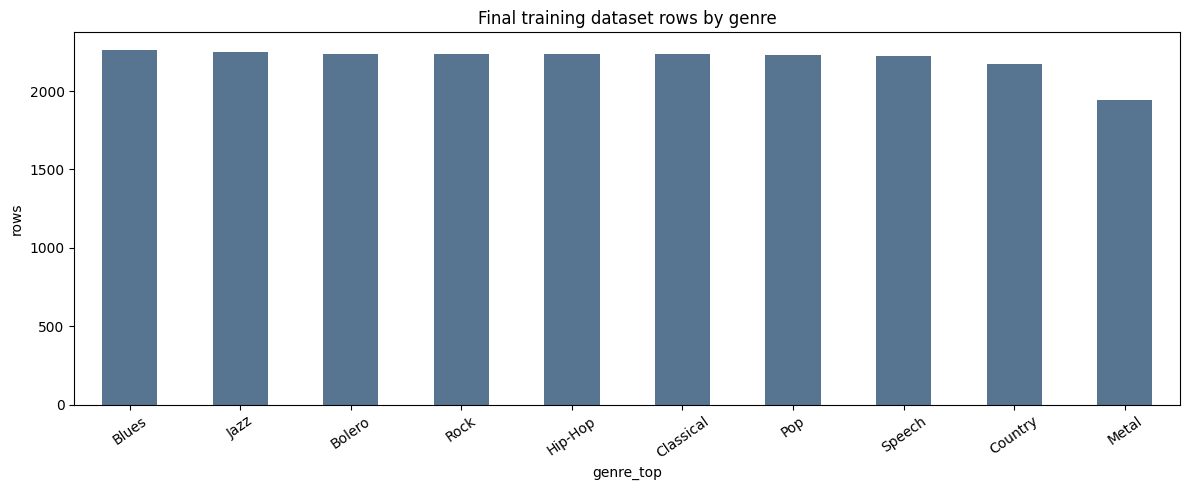

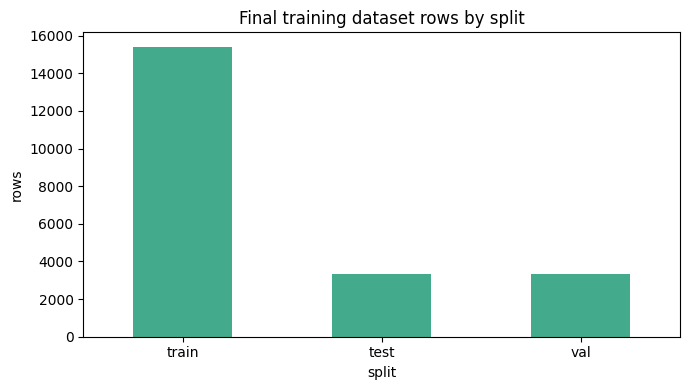

In [37]:
training_dataset_source = 'tfrecord_manifest_all'
training_dataset_df = None
training_split_col = None

if tfrecord_all_df is not None and not tfrecord_all_df.empty:
    training_dataset_df = tfrecord_all_df.copy()
    training_split_col = 'split_dir' if 'split_dir' in training_dataset_df.columns else None
elif expected_tfrecord_input_df is not None and not expected_tfrecord_input_df.empty:
    training_dataset_source = 'usable_logmel_handoff'
    training_dataset_df = expected_tfrecord_input_df.copy()
    training_split_col = 'final_split' if 'final_split' in training_dataset_df.columns else None

if training_dataset_df is None or training_dataset_df.empty:
    print('No live downstream training dataset summary is available because neither TFRecord manifests nor the usable log-mel handoff table is populated.')
else:
    if training_split_col is None:
        training_dataset_df['training_split_view'] = 'unknown'
        training_split_col = 'training_split_view'

    if 'label_int' in training_dataset_df.columns and 'genre_top' in training_dataset_df.columns:
        class_mapping_table = (
            training_dataset_df[['label_int', 'genre_top']]
            .drop_duplicates()
            .sort_values(['label_int', 'genre_top'])
            .reset_index(drop=True)
        )
    elif 'genre_top' in training_dataset_df.columns:
        class_mapping_table = pd.DataFrame({
            'label_int': range(len(sorted(training_dataset_df['genre_top'].dropna().astype(str).unique()))),
            'genre_top': sorted(training_dataset_df['genre_top'].dropna().astype(str).unique()),
        })
    else:
        class_mapping_table = pd.DataFrame(columns=['label_int', 'genre_top'])

    training_genre_list = class_mapping_table['genre_top'].dropna().astype(str).tolist() if 'genre_top' in class_mapping_table.columns else []
    observed_split_order = [split for split in ['train', 'training', 'val', 'validation', 'test'] if split in training_dataset_df[training_split_col].astype(str).unique()]
    if not observed_split_order:
        observed_split_order = sorted(training_dataset_df[training_split_col].astype(str).unique().tolist())

    training_dataset_overview = pd.DataFrame([
        {'metric': 'dataset_source', 'value': training_dataset_source},
        {'metric': 'total_rows', 'value': len(training_dataset_df)},
        {'metric': 'n_classes', 'value': int(class_mapping_table['genre_top'].nunique()) if 'genre_top' in class_mapping_table.columns else 0},
        {'metric': 'genre_list', 'value': ', '.join(training_genre_list)},
        {'metric': 'sample_length_sec', 'value': float(training_dataset_df['sample_length_sec'].dropna().iloc[0]) if 'sample_length_sec' in training_dataset_df.columns and training_dataset_df['sample_length_sec'].notna().any() else None},
        {'metric': 'split_column', 'value': training_split_col},
    ])
    display(Markdown('### Final Training Dataset Overview'))
    display(training_dataset_overview)

    display(Markdown('### Final Training Dataset Classes'))
    display(class_mapping_table)

    split_counts_table = (
        training_dataset_df[training_split_col]
        .astype(str)
        .value_counts()
        .reindex(observed_split_order, fill_value=0)
        .rename_axis('split')
        .reset_index(name='rows')
    )
    split_counts_table['share_pct'] = (split_counts_table['rows'] / max(len(training_dataset_df), 1) * 100).round(2)
    display(Markdown('### Final Training Dataset Split Sizes'))
    display(split_counts_table)

    if 'genre_top' in training_dataset_df.columns:
        genre_counts_table = (
            training_dataset_df['genre_top']
            .astype(str)
            .value_counts()
            .rename_axis('genre_top')
            .reset_index(name='rows')
        )
        genre_counts_table['share_pct'] = (genre_counts_table['rows'] / max(len(training_dataset_df), 1) * 100).round(2)
        display(Markdown('### Final Training Dataset Samples by Genre'))
        display(genre_counts_table)

        genre_split_counts_table = pd.crosstab(
            training_dataset_df['genre_top'].astype(str),
            training_dataset_df[training_split_col].astype(str),
        ).reindex(columns=observed_split_order, fill_value=0)
        genre_split_pct_table = genre_split_counts_table.div(genre_split_counts_table.sum(axis=1), axis=0).mul(100).round(2)

        display(Markdown('### Final Training Dataset Samples by Genre and Split'))
        display(genre_split_counts_table)
        display(genre_split_pct_table)
        plot_heatmap(
            genre_split_counts_table.astype(float),
            title='Final training dataset rows by genre and split',
            figsize=(10, 6),
            fmt='.0f',
        )

        plot_bar(
            genre_counts_table.set_index('genre_top')['rows'],
            title='Final training dataset rows by genre',
            xlabel='genre_top',
            ylabel='rows',
            rotation=35,
            figsize=(12, 5),
            color='#577590',
        )

    plot_bar(
        split_counts_table.set_index('split')['rows'],
        title='Final training dataset rows by split',
        xlabel='split',
        ylabel='rows',
        rotation=0,
        figsize=(7, 4),
        color='#43AA8B',
    )

In [33]:
final_split_counts = final_samples_df['final_split'].value_counts()
smallest_final_genre = final_samples_df['genre_top'].value_counts().idxmin() if not final_samples_df.empty else 'N/A'
dominant_file_genre = all_datasets_df['genre_top'].value_counts().idxmax() if not all_datasets_df.empty else 'N/A'
top_reason_code = all_datasets_df['reason_code'].value_counts().idxmax() if not all_datasets_df.empty else 'N/A'
mean_emitted_segments = round(all_samples_audio_summary['emitted_segments'].mean(), 2) if not all_samples_audio_summary.empty else 0
training_share_pct = round(final_split_counts.get('training', 0) / max(len(final_samples_df), 1) * 100, 2)
mean_genre_additional_gap_pct = round(genre_source_pct['gap_vs_target_pct'].abs().mean(), 2) if 'genre_source_pct' in globals() and not genre_source_pct.empty else 0

logmel_ready = logmel_all_df is not None
tfrecord_ready = tfrecord_all_df is not None
logmel_build_report_ready = bool(logmel_report_preview)
tfrecord_build_report_ready = bool(tfrecord_report_preview)
training_report_ready = isinstance(run_report, dict)
logmel_alignment_rate_pct = round(100 * int((logmel_alignment['_merge'] == 'both').sum()) / max(len(final_target_eligible_df), 1), 2) if 'logmel_alignment' in globals() else 0
tfrecord_alignment_rate_pct = round(100 * int((tfrecord_alignment['_merge'] == 'both').sum()) / max(len(expected_tfrecord_input_df), 1), 2) if 'tfrecord_alignment' in globals() else 0
latest_run_id = run_report.get('run_id') if isinstance(run_report, dict) else 'N/A'
latest_feature_shape = run_report.get('feature_config', {}).get('logmel_shape') if isinstance(run_report, dict) else 'N/A'
latest_train_samples = run_report.get('dataset', {}).get('train_samples') if isinstance(run_report, dict) else 'N/A'
latest_val_samples = run_report.get('dataset', {}).get('val_samples') if isinstance(run_report, dict) else 'N/A'
latest_test_samples = run_report.get('dataset', {}).get('test_samples') if isinstance(run_report, dict) else 'N/A'

supplementation_status = 'available' if supplementation_audit_ready else 'not available'
supplementation_non_fma_state = current_has_non_fma_rows if supplementation_audit_ready else 'unknown'
supplementation_payload_rows = selected_payload_rows if 'selected_payload_rows' in globals() else 0
supplementation_official_delta = official_current_row_delta if supplementation_audit_ready else 'unknown'
supplementation_new_genres = new_genres_vs_official_small if supplementation_audit_ready else []

summary_markdown = f'''
## Key Findings and Readiness Summary

This closing summary reflects the full audit path: staged stage 1 discovery, source-specific sample expansion, stage 2 final split selection, optional small-split supplementation state, log-mel materialization, TFRecord conversion, and optional downstream training metadata when present.

1. The file-level discovered dataset is currently dominated by **{dominant_file_genre}**.
2. The most frequent file-level reason code is **{top_reason_code}**.
3. The stage 1 segment-expansion outputs emit an average of **{mean_emitted_segments}** segments per source audio that produced samples.
4. The final manifest assigns **{training_share_pct}%** of selected segment rows to the training split.
5. The configured additional-source target is **{additional_ratio_target_pct}%**, while the current selected manifest achieves **{overall_additional_share_pct}%** overall.
6. The mean absolute per-genre gap versus the configured additional-source target is **{mean_genre_additional_gap_pct} percentage points**.
7. The least represented final genre is **{smallest_final_genre}**.
8. Leakage validation reports **{leakage_count}** source-audio artifacts assigned to more than one final split.
9. Log-mel dataset availability under the detected root is **{logmel_ready}** with **{logmel_alignment_rate_pct}%** alignment across target-genre-eligible final-manifest rows.
10. TFRecord dataset availability under the detected root is **{tfrecord_ready}** with **{tfrecord_alignment_rate_pct}%** alignment across usable log-mel rows expected to reach TFRecord conversion.
11. Final-manifest rows intentionally excluded by configured target genres: **{len(final_target_excluded_df)}**.
12. Eligible rows matched in log-mel but skipped during feature extraction: **{logmel_skipped_rows}**.
13. Unexpected missing log-mel rows among target-genre-eligible samples: **{logmel_missing_rows_from_eligible}**.
14. Unexpected missing TFRecord rows among usable log-mel samples: **{tfrecord_missing_rows_from_usable_logmels}**.
15. Log-mel build report availability is **{logmel_build_report_ready}**.
16. TFRecord build report availability is **{tfrecord_build_report_ready}**.
17. Optional downstream training run report availability is **{training_report_ready}**.
18. Latest training run id is **{latest_run_id}** with feature shape **{latest_feature_shape}**.
19. Latest training dataset counts are train **{latest_train_samples}**, val **{latest_val_samples}**, test **{latest_test_samples}**.
20. Supplementation-aware small-split audit availability is **{supplementation_status}**.
21. Current processed small-split delta versus official exact-small is **{supplementation_official_delta}** rows.
22. Non-FMA rows already present in processed small splits: **{supplementation_non_fma_state}**.
23. Selected supplementation payload rows currently visible in `extra_samples_for_small_dataset.json`: **{supplementation_payload_rows}**.
24. Genres outside official exact-small currently present in processed small splits: **{supplementation_new_genres}**.

Operational interpretation:

- the processed manifest layer is still the primary source of truth for this notebook
- the notebook now aligns to the staged preprocessing command sequence instead of assuming a training run already happened
- stage 1 is audited through separate FMA and additional-source manifests before recombination
- stage 2 remains the segment-level training contract consumed by downstream feature generation
- downstream alignment now distinguishes expected target-genre exclusions from actual downstream gaps
- downstream TFRecord expectations are measured from usable log-mel rows instead of all final-manifest rows
- downstream log-mel and TFRecord roots are resolved from the configured sample length first, with latest-generated cache roots as fallback
- downstream training metadata is inspected only when present, so the notebook still works after preprocessing stops at TFRecord conversion
- the small-split supplementation section still distinguishes between live processed parquets and staged payload candidates instead of assuming they are synchronized
'''
display(Markdown(summary_markdown))


## Key Findings and Readiness Summary

This closing summary reflects the full audit path: staged stage 1 discovery, source-specific sample expansion, stage 2 final split selection, optional small-split supplementation state, log-mel materialization, TFRecord conversion, and optional downstream training metadata when present.

1. The file-level discovered dataset is currently dominated by **Rock**.
2. The most frequent file-level reason code is **OK**.
3. The stage 1 segment-expansion outputs emit an average of **2.0** segments per source audio that produced samples.
4. The final manifest assigns **69.97%** of selected segment rows to the training split.
5. The configured additional-source target is **70.0%**, while the current selected manifest achieves **76.01%** overall.
6. The mean absolute per-genre gap versus the configured additional-source target is **19.42 percentage points**.
7. The least represented final genre is **Metal**.
8. Leakage validation reports **0** source-audio artifacts assigned to more than one final split.
9. Log-mel dataset availability under the detected root is **True** with **100.0%** alignment across target-genre-eligible final-manifest rows.
10. TFRecord dataset availability under the detected root is **True** with **100.0%** alignment across usable log-mel rows expected to reach TFRecord conversion.
11. Final-manifest rows intentionally excluded by configured target genres: **2302**.
12. Eligible rows matched in log-mel but skipped during feature extraction: **634**.
13. Unexpected missing log-mel rows among target-genre-eligible samples: **0**.
14. Unexpected missing TFRecord rows among usable log-mel samples: **0**.
15. Log-mel build report availability is **True**.
16. TFRecord build report availability is **True**.
17. Optional downstream training run report availability is **True**.
18. Latest training run id is **logmel-cnn-20260321-070615** with feature shape **None**.
19. Latest training dataset counts are train **6396**, val **800**, test **800**.
20. Supplementation-aware small-split audit availability is **not available**.
21. Current processed small-split delta versus official exact-small is **unknown** rows.
22. Non-FMA rows already present in processed small splits: **unknown**.
23. Selected supplementation payload rows currently visible in `extra_samples_for_small_dataset.json`: **0**.
24. Genres outside official exact-small currently present in processed small splits: **[]**.

Operational interpretation:

- the processed manifest layer is still the primary source of truth for this notebook
- the notebook now aligns to the staged preprocessing command sequence instead of assuming a training run already happened
- stage 1 is audited through separate FMA and additional-source manifests before recombination
- stage 2 remains the segment-level training contract consumed by downstream feature generation
- downstream alignment now distinguishes expected target-genre exclusions from actual downstream gaps
- downstream TFRecord expectations are measured from usable log-mel rows instead of all final-manifest rows
- downstream log-mel and TFRecord roots are resolved from the configured sample length first, with latest-generated cache roots as fallback
- downstream training metadata is inspected only when present, so the notebook still works after preprocessing stops at TFRecord conversion
- the small-split supplementation section still distinguishes between live processed parquets and staged payload candidates instead of assuming they are synchronized
